# TCN-Transformer Log Anomaly Notebook

Run All и всё. Тетрадка сама проходит по нескольким датасетам, при необходимости готовит данные, запускает обучение/evaluation/report assets и показывает общие метрики. Код моделей, XAI, графиков и preprocessing остаётся в `src/` и `scripts/`.


In [1]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_config, save_config
import src.utils.notebook_workflow as notebook_workflow
notebook_workflow = importlib.reload(notebook_workflow)
dataset_links_table = notebook_workflow.dataset_links_table
load_metric_tables_many = notebook_workflow.load_metric_tables_many
load_training_histories_many = notebook_workflow.load_training_histories_many
make_notebook_config = notebook_workflow.make_notebook_config
make_full_data_config = notebook_workflow.make_full_data_config
make_memory_saver_config = notebook_workflow.make_memory_saver_config
split_label_summary = notebook_workflow.split_label_summary
real_vs_synthetic_label_summary = notebook_workflow.real_vs_synthetic_label_summary
preparation_level_summary = notebook_workflow.preparation_level_summary
detailed_label_summary = notebook_workflow.detailed_label_summary
config_audit_table = notebook_workflow.config_audit_table
expected_detection_counts = notebook_workflow.expected_detection_counts
run_stage = notebook_workflow.run_stage
cuda_status = notebook_workflow.cuda_status
ensure_loghub_gold_labels = notebook_workflow.ensure_loghub_gold_labels

PROJECT_ROOT


PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer')

## Настройки

По умолчанию запускаются только loghub2 и rcaeval в RAM-safe режиме. LO2 оставлен в конфигах, но исключён из активной разметки/обучения.


In [2]:
from pathlib import Path
import sys
import importlib

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import load_config, save_config
import src.utils.notebook_workflow as notebook_workflow
notebook_workflow = importlib.reload(notebook_workflow)

dataset_links_table = notebook_workflow.dataset_links_table
load_metric_tables_many = notebook_workflow.load_metric_tables_many
load_training_histories_many = notebook_workflow.load_training_histories_many
make_notebook_config = notebook_workflow.make_notebook_config
make_full_data_config = notebook_workflow.make_full_data_config
make_memory_saver_config = notebook_workflow.make_memory_saver_config
split_label_summary = notebook_workflow.split_label_summary
real_vs_synthetic_label_summary = notebook_workflow.real_vs_synthetic_label_summary
preparation_level_summary = notebook_workflow.preparation_level_summary
detailed_label_summary = notebook_workflow.detailed_label_summary
config_audit_table = notebook_workflow.config_audit_table
expected_detection_counts = notebook_workflow.expected_detection_counts
run_stage = notebook_workflow.run_stage
cuda_status = notebook_workflow.cuda_status
ensure_loghub_gold_labels = notebook_workflow.ensure_loghub_gold_labels

DATASETS = ['loghub2_observation_v2', 'rcaeval_reconstruction_v3']  # варианты: 'loghub2_observation_v2', 'rcaeval_reconstruction_v3', 'rcaeval_observation_v2', 'loghub2', 'rcaeval', 'lo2', 'demo'
FORCE_PREPARE = True
FORCE_TRAIN = True  # поставь True, если надо переобучить уже существующие checkpoints на 100 эпох
RUN_ENSEMBLE = True
RUN_EVALUATION = True
RUN_REPORT = True
FULL_DATA = False  # True жрёт RAM: снимает caps и грузит весь raw сразу
MEMORY_SAVER = True  # щадящий RAM/VRAM режим для ноутбука
MEMORY_BATCH_SIZE = 64
TRAINING_NUM_WORKERS = 0  # важно для Jupyter/sandbox; GPU при этом используется
MAX_LOCALIZATION_SAMPLES = 128  # сколько synthetic samples брать для XAI/heatmap
TRAINING_EPOCHS = 1000
TRAINING_PATIENCE = 8
NOTEBOOK_COMPACT_LOGS = False  # не чистим training logs, чтобы можно было листать эпохи
print({'cuda': cuda_status()})

CONFIG_BY_DATASET = {
    'lo2': PROJECT_ROOT / 'configs' / 'experiment_lo2.yaml',
    'loghub2': PROJECT_ROOT / 'configs' / 'experiment_loghub.yaml',
    'loghub2_observation_v2': PROJECT_ROOT / 'configs' / 'experiment_loghub_observation_v2.yaml',
    'rcaeval': PROJECT_ROOT / 'configs' / 'experiment_rcaeval.yaml',
    'rcaeval_observation_v2': PROJECT_ROOT / 'configs' / 'experiment_rcaeval_observation_v2.yaml',
    'rcaeval_reconstruction_v3': PROJECT_ROOT / 'configs' / 'experiment_rcaeval_reconstruction_v3.yaml',
    'demo': PROJECT_ROOT / 'configs' / 'experiment_demo.yaml',
}

DATASET_STATE = {}
for dataset_name in DATASETS:
    if load_config(CONFIG_BY_DATASET[dataset_name])['data']['dataset_name'] == 'loghub2':
        label_path = ensure_loghub_gold_labels(PROJECT_ROOT / 'data' / 'raw' / 'loghub2')
        print(f'Loghub gold labels: {label_path}')
    base_config_path = CONFIG_BY_DATASET[dataset_name]
    base_config = load_config(base_config_path)
    output_dir = PROJECT_ROOT / 'outputs' / dataset_name
    config_factory = make_full_data_config if FULL_DATA else make_notebook_config
    notebook_config_path = config_factory(base_config_path, dataset_name=dataset_name, output_dir=output_dir)
    if MEMORY_SAVER:
        notebook_config_path = make_memory_saver_config(
            notebook_config_path,
            dataset_name=dataset_name,
            output_dir=output_dir,
            batch_size=MEMORY_BATCH_SIZE,
            max_localization_samples=MAX_LOCALIZATION_SAMPLES,
            epochs=TRAINING_EPOCHS,
            patience=TRAINING_PATIENCE,
            num_workers=TRAINING_NUM_WORKERS,
        )
    notebook_config = load_config(notebook_config_path)
    used_config_path = PROJECT_ROOT / notebook_config['data']['processed_dir'] / 'used_config.yaml'
    DATASET_STATE[dataset_name] = {
        'base_config_path': base_config_path,
        'notebook_config_path': notebook_config_path,
        'used_config_path': used_config_path,
        'output_dir': output_dir,
    }

DATASET_STATE


{'cuda': {'torch': '2.10.0+cu126', 'cuda_available': True, 'cuda_version': '12.6', 'device_count': 1, 'device_name': 'NVIDIA GeForce RTX 3060'}}
Loghub gold labels: /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/raw/loghub2/anomaly_label.csv


{'loghub2_observation_v2': {'base_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/configs/experiment_loghub_observation_v2.yaml'),
  'notebook_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/loghub2_observation_v2_memory_saver_notebook_config.yaml'),
  'used_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/loghub2_observation_v2/used_config.yaml'),
  'output_dir': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/loghub2_observation_v2')},
 'rcaeval_reconstruction_v3': {'base_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/configs/experiment_rcaeval_reconstruction_v3.yaml'),
  'notebook_config_path': PosixPath('/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/rcaeval_reconstruction_v3_memory_saver_not

## Датасеты

Справка по источникам и папкам raw-данных.


In [3]:
print(f"lo2-sample.zip\nHDFS.zip\nRE1-OB.zip")

lo2-sample.zip
HDFS.zip
RE1-OB.zip


In [4]:
dataset_links_table()


,dataset,target_dir,url,note
0,lo2,data/raw/lo2 там 2 папки logs и metrics,https://doi.org/10.5281/zenodo.14265858,LO2 / Light-OAuth2 microservice API anomaly da...
1,loghub2,data/raw/loghub2 без папки тупо данные,https://zenodo.org/records/8275861,Loghub-2.0 collection. Put extracted log files...
2,rcaeval,data/raw/rcaeval папка сюда RE1-OB тупо копиро...,https://zenodo.org/records/14590730,RCAEval benchmark repository/data. Put extract...


## Баланс Данных

Перед обучением видно, сколько normal/anomaly уже лежит в подготовленных split-файлах. В RAM-safe режиме `FULL_DATA=False`, поэтому используются лимиты из YAML-конфигов и готовые splits переиспользуются, если они уже есть.


In [5]:
label_summary = split_label_summary(DATASET_STATE)
prep_levels = preparation_level_summary(DATASET_STATE)
real_synthetic_summary = real_vs_synthetic_label_summary(DATASET_STATE)
detailed_summary = detailed_label_summary(DATASET_STATE)

print('Уровни разметки: raw rows != windowed sequences != saved splits')
display(prep_levels)
print('ИТОГ по сохраненным split-файлам: train уже normal-only, это не raw rows')
real_synthetic_summary


Уровни разметки: raw rows != windowed sequences != saved splits


,dataset,level,normal,anomaly,total,description,status
0,loghub2_observation_v2,raw_rows,690668.0,677289.0,1367957,original log/event rows before session aggrega...,ok
1,loghub2_observation_v2,raw_sessions,NaN,NaN,29449,unique session_id values in raw dataframe,ok
2,loghub2_observation_v2,windowed_sequences_before_split,12616.0,16859.0,29475,model samples after session aggregation/window...,ok
3,loghub2_observation_v2,train_before_filter,12616.0,16859.0,29475,train split before keeping only normal samples...,ok
4,loghub2_observation_v2,saved_train_for_ae,12616.0,0.0,12616,saved train.json; anomalies are intentionally ...,ok
5,loghub2_observation_v2,saved_validation_for_loss,12616.0,0.0,12616,validation loss split; in no_split mode this i...,ok
6,loghub2_observation_v2,saved_test_real,12616.0,16859.0,29475,test.json; in no_split mode this is the full r...,ok
7,loghub2_observation_v2,saved_real_detection_val_test,12616.0,16859.0,29475,real samples used to measure detection; in no_...,ok
8,loghub2_observation_v2,saved_synthetic_val_test,12677.0,12555.0,25232,synthetic val+test samples used as auxiliary s...,ok
9,rcaeval_reconstruction_v3,raw_rows,989945.0,2075754.0,3065699,original log/event rows before session aggrega...,ok


ИТОГ по сохраненным split-файлам: train уже normal-only, это не raw rows


,dataset,source,normal,anomaly,total
0,loghub2_observation_v2,real,12616,16859,29475
1,loghub2_observation_v2,synthetic,12677,12555,25232
2,loghub2_observation_v2,real+synthetic,25293,29414,54707
3,rcaeval_reconstruction_v3,real,9032,34052,43084
4,rcaeval_reconstruction_v3,synthetic,9026,9038,18064
5,rcaeval_reconstruction_v3,real+synthetic,18058,43090,61148
6,ALL,real,21648,50911,72559
7,ALL,synthetic,21703,21593,43296
8,ALL,real+synthetic,43351,72504,115855


### Детализация По Split

Если нужно посмотреть train/val/test/test_synthetic отдельно, эта таблица ниже.


### Полная таблица: каждый split отдельно

Здесь видно, где именно normal/anomaly: train, val, val_synthetic, test, test_synthetic.


In [6]:
detailed_summary


,dataset,source,split,normal,anomaly,total,normal_pct,anomaly_pct,status
0,loghub2_observation_v2,real,train,12616,0,12616,100.00,0.00,ok
1,loghub2_observation_v2,real,val,12616,0,12616,100.00,0.00,ok
2,loghub2_observation_v2,synthetic,val_synthetic,6385,6231,12616,50.61,49.39,ok
3,loghub2_observation_v2,real,test,12616,16859,29475,42.80,57.20,ok
4,loghub2_observation_v2,synthetic,test_synthetic,6292,6324,12616,49.87,50.13,ok
5,loghub2_observation_v2,real_full,full_real,12616,16859,29475,42.80,57.20,ok
6,loghub2_observation_v2,real,real_total,37848,16859,54707,69.18,30.82,total
7,loghub2_observation_v2,synthetic,synthetic_total,12677,12555,25232,50.24,49.76,total
8,loghub2_observation_v2,real_full,real_full_total,12616,16859,29475,42.80,57.20,total
9,loghub2_observation_v2,real+synthetic,dataset_total,63141,46273,109414,57.71,42.29,total


## Разметка И Проверка Перед Обучением

Этот блок запускается до обучения. Он готовит split-файлы, подключает gold labels для Loghub/HDFS, проверяет конфиги и показывает, сколько normal/anomaly должно попасть в validation/test.


In [7]:
from IPython.display import display

LABELING_ALREADY_PREPARED = False

for dataset_name, state in DATASET_STATE.items():
    print('=' * 80)
    print(f'LABELING: {dataset_name}')
    print('=' * 80)
    if load_config(state['notebook_config_path'])['data']['dataset_name'] == 'loghub2':
        label_path = ensure_loghub_gold_labels(PROJECT_ROOT / 'data' / 'raw' / 'loghub2')
        print(f'Loghub gold labels: {label_path}')

    prepare_needed = FORCE_PREPARE or not state['used_config_path'].exists()
    if prepare_needed:
        print(f'Preparing labels/splits from {state["notebook_config_path"]} ...')
        run_stage('prepare_data', state['notebook_config_path'])
    else:
        print(f'Prepared labels/splits already exist: {state["used_config_path"]}')

LABELING_ALREADY_PREPARED = True

config_audit = config_audit_table(DATASET_STATE)
prep_levels = preparation_level_summary(DATASET_STATE)
label_summary = split_label_summary(DATASET_STATE)
real_synthetic_summary = real_vs_synthetic_label_summary(DATASET_STATE)
detailed_summary = detailed_label_summary(DATASET_STATE)
expected_counts = expected_detection_counts(DATASET_STATE)

print('Проверка подключенных конфигов/model settings:')
display(config_audit)
print('Почему цифры отличаются: разные уровни разметки от raw rows до target для detection:')
display(prep_levels)
print('Сколько модель должна обнаружить после разметки:')
display(expected_counts)
print('Детализация по split:')
display(detailed_summary)


LABELING: loghub2_observation_v2
Loghub gold labels: /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/raw/loghub2/anomaly_label.csv
Preparing labels/splits from /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/loghub2_observation_v2_memory_saver_notebook_config.yaml ...
Loading raw dataset=loghub2 from /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/raw/loghub2
Loghub block-complete budget: rows=600,000 blocks=29,449 normal_blocks=12,611 anomaly_blocks=16,838
Loaded rows=1,367,957 sessions=29,449 labels={0: 690668, 1: 677289}
Cleaning messages and building event templates...
Building vocab from normal rows only: 690,668/1,367,957
Built vocab_size=166 unk_encoded_rows=110,927; building sequences...
Sequences=29,475 label_counts={0: 12616, 1: 16859}
Prepared. mode=no_split_full_real vocab=166 train_normal=12616 val=12616 test=29475 synthetic=12616
Label summary: train={0: 12616, 1: 0} val={0: 12616, 1

,dataset,status,config_path,raw_dir,splits_dir,output_dir,vocab_size,d_model,tcn_layers,transformer_layers,...,device,num_workers,threshold_policy,validation_safety_check,adaptive_method,adaptive_k,ensemble_enabled,ensemble_seeds,evaluation_models,loghub_gold_labels
0,loghub2_observation_v2,ok,/home/danderety/Documents/GitHub/TCN_Transform...,/home/danderety/Documents/GitHub/TCN_Transform...,/home/danderety/Documents/GitHub/TCN_Transform...,/home/danderety/Documents/GitHub/TCN_Transform...,166,96,3,2,...,cuda,0,raw,False,robust_mad,4.0,True,"[42, 43, 44]","[tcn_ae, tcn_transformer_ae, tcn_transformer_a...",/home/danderety/Documents/GitHub/TCN_Transform...
1,rcaeval_reconstruction_v3,ok,/home/danderety/Documents/GitHub/TCN_Transform...,/home/danderety/Documents/GitHub/TCN_Transform...,/home/danderety/Documents/GitHub/TCN_Transform...,/home/danderety/Documents/GitHub/TCN_Transform...,1948,128,4,2,...,cuda,0,raw,False,robust_mad,2.0,True,"[42, 43, 44]","[tcn_ae, tcn_transformer_ae, tcn_transformer_a...",


Почему цифры отличаются: разные уровни разметки от raw rows до target для detection:


,dataset,level,normal,anomaly,total,description,status
0,loghub2_observation_v2,raw_rows,690668.0,677289.0,1367957,original log/event rows before session aggrega...,ok
1,loghub2_observation_v2,raw_sessions,NaN,NaN,29449,unique session_id values in raw dataframe,ok
2,loghub2_observation_v2,windowed_sequences_before_split,12616.0,16859.0,29475,model samples after session aggregation/window...,ok
3,loghub2_observation_v2,train_before_filter,12616.0,16859.0,29475,train split before keeping only normal samples...,ok
4,loghub2_observation_v2,saved_train_for_ae,12616.0,0.0,12616,saved train.json; anomalies are intentionally ...,ok
5,loghub2_observation_v2,saved_validation_for_loss,12616.0,0.0,12616,validation loss split; in no_split mode this i...,ok
6,loghub2_observation_v2,saved_test_real,12616.0,16859.0,29475,test.json; in no_split mode this is the full r...,ok
7,loghub2_observation_v2,saved_real_detection_val_test,12616.0,16859.0,29475,real samples used to measure detection; in no_...,ok
8,loghub2_observation_v2,saved_synthetic_val_test,12677.0,12555.0,25232,synthetic val+test samples used as auxiliary s...,ok
9,rcaeval_reconstruction_v3,raw_rows,989945.0,2075754.0,3065699,original log/event rows before session aggrega...,ok


Сколько модель должна обнаружить после разметки:


,dataset,train_normal_for_ae,train_anomaly_excluded,val_should_detect_anomaly,val_normal,test_should_detect_anomaly,test_normal,real_should_detect_anomaly_val_test,real_normal_val_test,synthetic_should_detect_anomaly,synthetic_normal,real_total
0,loghub2_observation_v2,12616,0,0,12616,16859,12616,16859,12616,12555,12677,29475
1,rcaeval_reconstruction_v3,9032,0,0,9032,34052,9032,34052,9032,9038,9026,43084


Детализация по split:


,dataset,source,split,normal,anomaly,total,normal_pct,anomaly_pct,status
0,loghub2_observation_v2,real,train,12616,0,12616,100.00,0.00,ok
1,loghub2_observation_v2,real,val,12616,0,12616,100.00,0.00,ok
2,loghub2_observation_v2,synthetic,val_synthetic,6385,6231,12616,50.61,49.39,ok
3,loghub2_observation_v2,real,test,12616,16859,29475,42.80,57.20,ok
4,loghub2_observation_v2,synthetic,test_synthetic,6292,6324,12616,49.87,50.13,ok
5,loghub2_observation_v2,real_full,full_real,12616,16859,29475,42.80,57.20,ok
6,loghub2_observation_v2,real,real_total,37848,16859,54707,69.18,30.82,total
7,loghub2_observation_v2,synthetic,synthetic_total,12677,12555,25232,50.24,49.76,total
8,loghub2_observation_v2,real_full,real_full_total,12616,16859,29475,42.80,57.20,total
9,loghub2_observation_v2,real+synthetic,dataset_total,63141,46273,109414,57.71,42.29,total


## Автозапуск Pipeline По Всем Датасетам

Эта ячейка делает всю работу. Для каждого датасета результаты пишутся в свою папку: `outputs/lo2`, `outputs/loghub2`, `outputs/rcaeval`.


In [8]:
def model_checkpoint(output_dir, model_name):
    return output_dir / 'models' / f'{model_name}_best.pt'

for dataset_name, state in DATASET_STATE.items():
    if load_config(state['notebook_config_path'])['data']['dataset_name'] == 'loghub2':
        label_path = ensure_loghub_gold_labels(PROJECT_ROOT / 'data' / 'raw' / 'loghub2')
        print(f'Loghub gold labels: {label_path}')
    print('=' * 80)
    print(f'DATASET: {dataset_name}')
    print('=' * 80)

    prepare_needed = (FORCE_PREPARE and not globals().get('LABELING_ALREADY_PREPARED', False)) or not state['used_config_path'].exists()
    if prepare_needed:
        print(f'Preparing data from {state["notebook_config_path"]} ...')
        run_stage('prepare_data', state['notebook_config_path'])
    else:
        print(f'Prepared config already exists: {state["used_config_path"]}')

    config_path_for_run = state['used_config_path'] if state['used_config_path'].exists() else state['notebook_config_path']
    if MEMORY_SAVER:
        config_path_for_run = make_memory_saver_config(
            config_path_for_run,
            dataset_name=dataset_name,
            output_dir=state['output_dir'],
            batch_size=MEMORY_BATCH_SIZE,
            max_localization_samples=MAX_LOCALIZATION_SAMPLES,
            epochs=TRAINING_EPOCHS,
            patience=TRAINING_PATIENCE,
            num_workers=TRAINING_NUM_WORKERS,
        )
    else:
        config_path_for_run = make_notebook_config(config_path_for_run, dataset_name=dataset_name, output_dir=state['output_dir'])

    config = load_config(config_path_for_run)
    config.setdefault('notebook', {})['compact_training_log'] = NOTEBOOK_COMPACT_LOGS
    save_config(config, config_path_for_run)
    config = load_config(config_path_for_run)

    training = config['training']
    print({
        'config': str(config_path_for_run),
        'output_dir': config['project']['output_dir'],
        'epochs': training['epochs'],
        'patience': training['patience'],
        'batch_size': training['batch_size'],
        'device': training['device'],
        'target_recall': config.get('threshold', {}).get('target_recall'),
    })

    if 'expected_counts' in globals():
        print('Expected labels for this dataset:')
        display(expected_counts[expected_counts['dataset'] == dataset_name])

    requested_models = set(config.get('evaluation', {}).get('models') or ['tcn_ae', 'tcn_transformer_ae'])
    for model_name, stage in [('tcn_ae', 'train_tcn_ae'), ('tcn_transformer_ae', 'train_tcn_transformer_ae')]:
        if model_name not in requested_models:
            print(f'Skip training {dataset_name}/{model_name}: not listed in evaluation.models')
            continue
        ckpt = model_checkpoint(state['output_dir'], model_name)
        if FORCE_TRAIN or not ckpt.exists():
            print()
            print(f'Training {dataset_name}/{model_name} ...')
            run_stage(stage, config_path_for_run)
        else:
            print(f'Skip training {dataset_name}/{model_name}: checkpoint exists -> {ckpt}')

    ensemble_enabled = bool(config.get('ensemble', {}).get('enabled', False)) and RUN_ENSEMBLE
    if ensemble_enabled:
        member_seeds = config.get('ensemble', {}).get('member_seeds', [])
        missing_members = [
            seed for seed in member_seeds
            if not (state['output_dir'] / 'models' / f'tcn_transformer_ae_seed{int(seed)}_best.pt').exists()
        ]
        if FORCE_TRAIN or missing_members:
            print()
            print(f'Training {dataset_name}/transformer ensemble; missing_members={missing_members}')
            run_stage('train_tcn_transformer_ensemble', config_path_for_run)
        else:
            print(f'Skip ensemble training for {dataset_name}: all member checkpoints exist')
    else:
        print(f'Skip ensemble training for {dataset_name}: disabled by config or RUN_ENSEMBLE=False')

    if RUN_EVALUATION:
        for stage in ['evaluate_detection', 'evaluate_localization', 'evaluate_adaptive_threshold']:
            print()
            print(f'Running {dataset_name}/{stage} ...')
            run_stage(stage, config_path_for_run)

    if RUN_REPORT:
        print()
        print(f'Generating report assets for {dataset_name} ...')
        run_stage('generate_report_assets', config_path_for_run)

print()
print('Done. Per-dataset outputs are in outputs/<dataset_name>/.')


Loghub gold labels: /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/raw/loghub2/anomaly_label.csv
DATASET: loghub2_observation_v2
Prepared config already exists: /home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/data/processed/loghub2_observation_v2/used_config.yaml
{'config': '/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/_notebook_configs/loghub2_observation_v2_memory_saver_notebook_config.yaml', 'output_dir': '/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/loghub2_observation_v2', 'epochs': 1000, 'patience': 8, 'batch_size': 64, 'device': 'cuda', 'target_recall': 0.99}
Expected labels for this dataset:


,dataset,train_normal_for_ae,train_anomaly_excluded,val_should_detect_anomaly,val_normal,test_should_detect_anomaly,test_normal,real_should_detect_anomaly_val_test,real_normal_val_test,synthetic_should_detect_anomaly,synthetic_normal,real_total
0,loghub2_observation_v2,12616,0,0,12616,16859,12616,16859,12616,12555,12677,29475



Training loghub2_observation_v2/tcn_ae ...
tcn_ae: start training | epochs=1000 patience=8 threshold_patience=9 threshold_monitor_interval=5 batch_size=64 device=cuda params=198,502 val_monitor=real_val_plus_val_synthetic best_checkpoint=/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/loghub2_observation_v2/models/tcn_ae_best.pt
tcn_ae epoch=001/1000 train_loss=0.9538 val_loss=0.0260 val_f1=0.1070 val_recall=0.0583 val_fp=194 val_fn=5868 thr=27.2869 thr_move=False det_gain=True safety=False best_val_loss=0.0260 BEST saved time=5.6s
tcn_ae epoch=002/1000 train_loss=0.0220 val_loss=0.0078 best_val_loss=0.0078 BEST saved time=1.5s
tcn_ae epoch=003/1000 train_loss=0.0094 val_loss=0.0043 best_val_loss=0.0043 BEST saved time=1.5s
tcn_ae epoch=004/1000 train_loss=0.0057 val_loss=0.0029 best_val_loss=0.0029 BEST saved time=1.5s
tcn_ae epoch=005/1000 train_loss=0.0040 val_loss=0.0021 val_f1=0.6421 val_recall=0.4876 val_fp=193 val_fn=3193 thr=123.529 thr_move=True det_

,dataset,train_normal_for_ae,train_anomaly_excluded,val_should_detect_anomaly,val_normal,test_should_detect_anomaly,test_normal,real_should_detect_anomaly_val_test,real_normal_val_test,synthetic_should_detect_anomaly,synthetic_normal,real_total
1,rcaeval_reconstruction_v3,9032,0,0,9032,34052,9032,34052,9032,9038,9026,43084



Training rcaeval_reconstruction_v3/tcn_ae ...
tcn_ae: start training | epochs=1000 patience=8 threshold_patience=9 threshold_monitor_interval=5 batch_size=64 device=cuda params=894,876 val_monitor=real_val_plus_val_synthetic best_checkpoint=/home/danderety/Documents/GitHub/TCN_Transformer_anomaly_analizer/outputs/rcaeval_reconstruction_v3/models/tcn_ae_best.pt
tcn_ae epoch=001/1000 train_loss=3.2255 val_loss=1.2083 val_f1=0.2970 val_recall=0.3579 val_fp=4765 val_fn=2908 thr=0.408036 thr_move=False det_gain=True safety=False best_val_loss=1.2083 BEST saved time=13.4s
tcn_ae epoch=002/1000 train_loss=0.6705 val_loss=0.2228 best_val_loss=0.2228 BEST saved time=2.4s
tcn_ae epoch=003/1000 train_loss=0.1881 val_loss=0.0709 best_val_loss=0.0709 BEST saved time=2.4s
tcn_ae epoch=004/1000 train_loss=0.0800 val_loss=0.0291 best_val_loss=0.0291 BEST saved time=2.3s
tcn_ae epoch=005/1000 train_loss=0.0422 val_loss=0.0138 val_f1=0.3629 val_recall=0.4557 val_fp=4781 val_fn=2465 thr=1.0498 thr_move=

## Общие Метрики

Таблицы ниже объединяют результаты из `outputs/<dataset>/metrics/` и добавляют колонку `dataset`.


In [9]:
OUTPUT_DIRS = {name: state['output_dir'] for name, state in DATASET_STATE.items()}
tables = load_metric_tables_many(OUTPUT_DIRS)
tables.keys()


dict_keys(['detection', 'localization', 'adaptive_threshold', 'final_comparison'])

In [10]:
tables.get('detection')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,...,val_f1,val_fp,val_fn,raw_val_fp,raw_val_fn,safe_val_fp,safe_val_fn,validation_monitor_source,ensemble_members,ensemble_seeds
0,loghub2_observation_v2,0.992486,0.994958,0.993720,0.999288,0.998783,12489,127,85,16774,...,0.709489,188,2702,188,2702,17472,56,real_val_plus_val_synthetic,NaN,NaN
1,loghub2_observation_v2,0.992465,0.992170,0.992318,0.999175,0.998581,12489,127,132,16727,...,0.443636,189,4401,189,4401,16846,60,real_val_plus_val_synthetic,NaN,NaN
2,loghub2_observation_v2,0.999875,0.950531,0.974579,0.999138,0.998520,12614,2,834,16025,...,0.277187,3,5228,3,5228,16846,60,real_val_plus_val_synthetic,3.0,42 43 44
3,rcaeval_reconstruction_v3,0.911030,0.950546,0.930369,0.985184,0.947817,5871,3161,1684,32368,...,0.378661,4771,2357,4771,2357,13284,45,real_val_plus_val_synthetic,NaN,NaN
4,rcaeval_reconstruction_v3,0.912894,0.972865,0.941926,0.983912,0.945772,5871,3161,924,33128,...,0.361573,4783,2474,4783,2474,13352,45,real_val_plus_val_synthetic,NaN,NaN
5,rcaeval_reconstruction_v3,0.999712,0.305327,0.467785,0.983939,0.945681,9029,3,23655,10397,...,0.044003,5,4427,5,4427,13346,45,real_val_plus_val_synthetic,3.0,42 43 44


In [11]:
tables.get('localization')


,dataset,top_1_hit,iou_at_1,top_3_hit,iou_at_3,top_5_hit,iou_at_5,mean_rank,model,xai_method,localization_source,ensemble_members,ensemble_seeds
0,loghub2_observation_v2,1.0,0.045582,1.0,0.136745,1.0,0.227909,1.0,tcn_ae,reconstruction_error_heatmap,real_test,NaN,NaN
1,loghub2_observation_v2,1.0,0.045582,1.0,0.136745,1.0,0.227909,1.0,tcn_transformer_ae,reconstruction_error_heatmap,real_test,NaN,NaN
2,loghub2_observation_v2,1.0,0.045582,1.0,0.136745,1.0,0.227909,1.0,tcn_transformer_ae,transformer_attention_received,real_test,NaN,NaN
3,loghub2_observation_v2,1.0,0.045582,1.0,0.136745,1.0,0.227909,1.0,tcn_transformer_ae_ensemble,ensemble_transformer_attention_received,real_test,3.0,42 43 44
4,rcaeval_reconstruction_v3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,tcn_ae,reconstruction_error_heatmap,real_test,NaN,NaN
5,rcaeval_reconstruction_v3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,tcn_transformer_ae,reconstruction_error_heatmap,real_test,NaN,NaN
6,rcaeval_reconstruction_v3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,tcn_transformer_ae,transformer_attention_received,real_test,NaN,NaN
7,rcaeval_reconstruction_v3,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.0,tcn_transformer_ae_ensemble,ensemble_transformer_attention_received,real_test,3.0,42 43 44


In [12]:
tables.get('adaptive_threshold')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,...,adaptive_method,adaptive_quantile,adaptive_warmup_trim_percentile,k,configured_k,adaptive_calibrate_k,adaptive_validation_f1,adaptive_validation_recall,adaptive_validation_fpr,validation_monitor_source
0,loghub2_observation_v2,0.833168,0.998280,0.908281,0.999288,0.998783,9246,3370,29,16830,...,robust_mad,99,95,4.0,4.0,False,NaN,NaN,NaN,real_val_plus_val_synthetic
1,rcaeval_reconstruction_v3,0.805211,0.997386,0.891055,0.985184,0.947817,816,8216,89,33963,...,robust_mad,99,95,0.5,2.0,True,0.413478,0.987635,0.933432,real_val_plus_val_synthetic


In [13]:
tables.get('final_comparison')


,dataset,precision,recall,f1,pr_auc,roc_auc,tn,fp,fn,tp,...,adaptive_window_size_config,adaptive_method,adaptive_quantile,adaptive_warmup_trim_percentile,k,configured_k,adaptive_calibrate_k,adaptive_validation_f1,adaptive_validation_recall,adaptive_validation_fpr
0,loghub2_observation_v2,0.992486,0.994958,0.993720,0.999288,0.998783,12489,127,85,16774,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,loghub2_observation_v2,0.992465,0.992170,0.992318,0.999175,0.998581,12489,127,132,16727,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,loghub2_observation_v2,0.999875,0.950531,0.974579,0.999138,0.998520,12614,2,834,16025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,loghub2_observation_v2,0.833168,0.998280,0.908281,0.999288,0.998783,9246,3370,29,16830,...,auto,robust_mad,99.0,95.0,4.0,4.0,False,NaN,NaN,NaN
4,rcaeval_reconstruction_v3,0.911030,0.950546,0.930369,0.985184,0.947817,5871,3161,1684,32368,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,rcaeval_reconstruction_v3,0.912894,0.972865,0.941926,0.983912,0.945772,5871,3161,924,33128,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,rcaeval_reconstruction_v3,0.999712,0.305327,0.467785,0.983939,0.945681,9029,3,23655,10397,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,rcaeval_reconstruction_v3,0.805211,0.997386,0.891055,0.985184,0.947817,816,8216,89,33963,...,auto,robust_mad,99.0,95.0,0.5,2.0,True,0.413478,0.987635,0.933432


## История Обучения

Все эпохи, `train_loss`, `val_loss`, validation recall/F1/FP/FN, threshold и `BEST saved` сохраняются в `outputs/<dataset>/metrics/*_training_history.csv`.


In [14]:
histories = load_training_histories_many(OUTPUT_DIRS)
histories.keys()


dict_keys(['loghub2_observation_v2/tcn_ae_training_history', 'loghub2_observation_v2/tcn_transformer_ae_seed42_training_history', 'loghub2_observation_v2/tcn_transformer_ae_seed43_training_history', 'loghub2_observation_v2/tcn_transformer_ae_seed44_training_history', 'loghub2_observation_v2/tcn_transformer_ae_training_history', 'rcaeval_reconstruction_v3/tcn_ae_training_history', 'rcaeval_reconstruction_v3/tcn_transformer_ae_seed42_training_history', 'rcaeval_reconstruction_v3/tcn_transformer_ae_seed43_training_history', 'rcaeval_reconstruction_v3/tcn_transformer_ae_seed44_training_history', 'rcaeval_reconstruction_v3/tcn_transformer_ae_training_history'])

In [15]:
next(iter(histories.values())) if histories else None


,model,epoch,epochs_total,train_loss,val_loss,stop_patience,threshold_patience,threshold_monitor_interval,best_val_loss_before_epoch,best_checkpoint_score_before_epoch,...,threshold_signal,threshold_checkpoint,threshold_save_loss_tolerance,checkpoint_score,best_checkpoint_score_after_epoch,is_best,best_val_loss_after_epoch,best_detection_score_after_epoch,patience_after_epoch,epoch_time_sec
0,tcn_ae,1,1000,0.953751,0.026014,9,9,5,NaN,NaN,...,True,False,0.05,0.026014,0.026014,True,0.026014,-5877.162428,0,5.551640
1,tcn_ae,2,1000,0.022048,0.007842,9,9,5,0.026014,0.026014,...,False,False,0.05,0.007842,0.007842,True,0.007842,-5877.162428,0,1.510610
2,tcn_ae,3,1000,0.009386,0.004329,9,9,5,0.007842,0.007842,...,False,False,0.05,0.004329,0.004329,True,0.004329,-5877.162428,0,1.510609
3,tcn_ae,4,1000,0.005659,0.002872,9,9,5,0.004329,0.004329,...,False,False,0.05,0.002872,0.002872,True,0.002872,-5877.162428,0,1.514304
4,tcn_ae,5,1000,0.003952,0.002108,9,9,5,0.002872,0.002872,...,True,True,0.05,0.002108,0.002108,True,0.002108,-3196.904826,0,5.267127
5,tcn_ae,6,1000,0.002884,0.001542,9,9,5,0.002108,0.002108,...,False,False,0.05,0.001542,0.001542,True,0.001542,-3196.904826,0,1.521695
6,tcn_ae,7,1000,0.002242,0.001150,9,9,5,0.001542,0.001542,...,False,False,0.05,0.001150,0.001150,True,0.001150,-3196.904826,0,1.526968
7,tcn_ae,8,1000,0.001794,0.000906,9,9,5,0.001150,0.001150,...,False,False,0.05,0.000906,0.000906,True,0.000906,-3196.904826,0,1.587491
8,tcn_ae,9,1000,0.001423,0.000678,9,9,5,0.000906,0.000906,...,False,False,0.05,0.000678,0.000678,True,0.000678,-3196.904826,0,1.556795
9,tcn_ae,10,1000,0.001131,0.000522,9,9,5,0.000678,0.000678,...,True,True,0.05,0.000522,0.000522,True,0.000522,-2887.315281,0,5.455283


## Где Смотреть Файлы

- `outputs/lo2/`, `outputs/loghub2/`, `outputs/rcaeval/` — отдельные результаты по датасетам.
- `outputs/<dataset>/models/` — checkpoints.
- `outputs/<dataset>/metrics/` — CSV-метрики и истории обучения.
- `outputs/<dataset>/predictions/` — scores, predictions, XAI JSON.
- `outputs/<dataset>/figures/` — heatmap/attention/summary PNG.
- `outputs/<dataset>/reports/summary.md` — markdown-сводка.


## Картинки По Датасетам

После `RUN_REPORT=True` здесь показываются сохранённые confusion matrices и общие heatmap по каждому датасету и модели.


### loghub2_observation_v2

**Матрицы ошибок**

`confusion_matrices_overview.png`

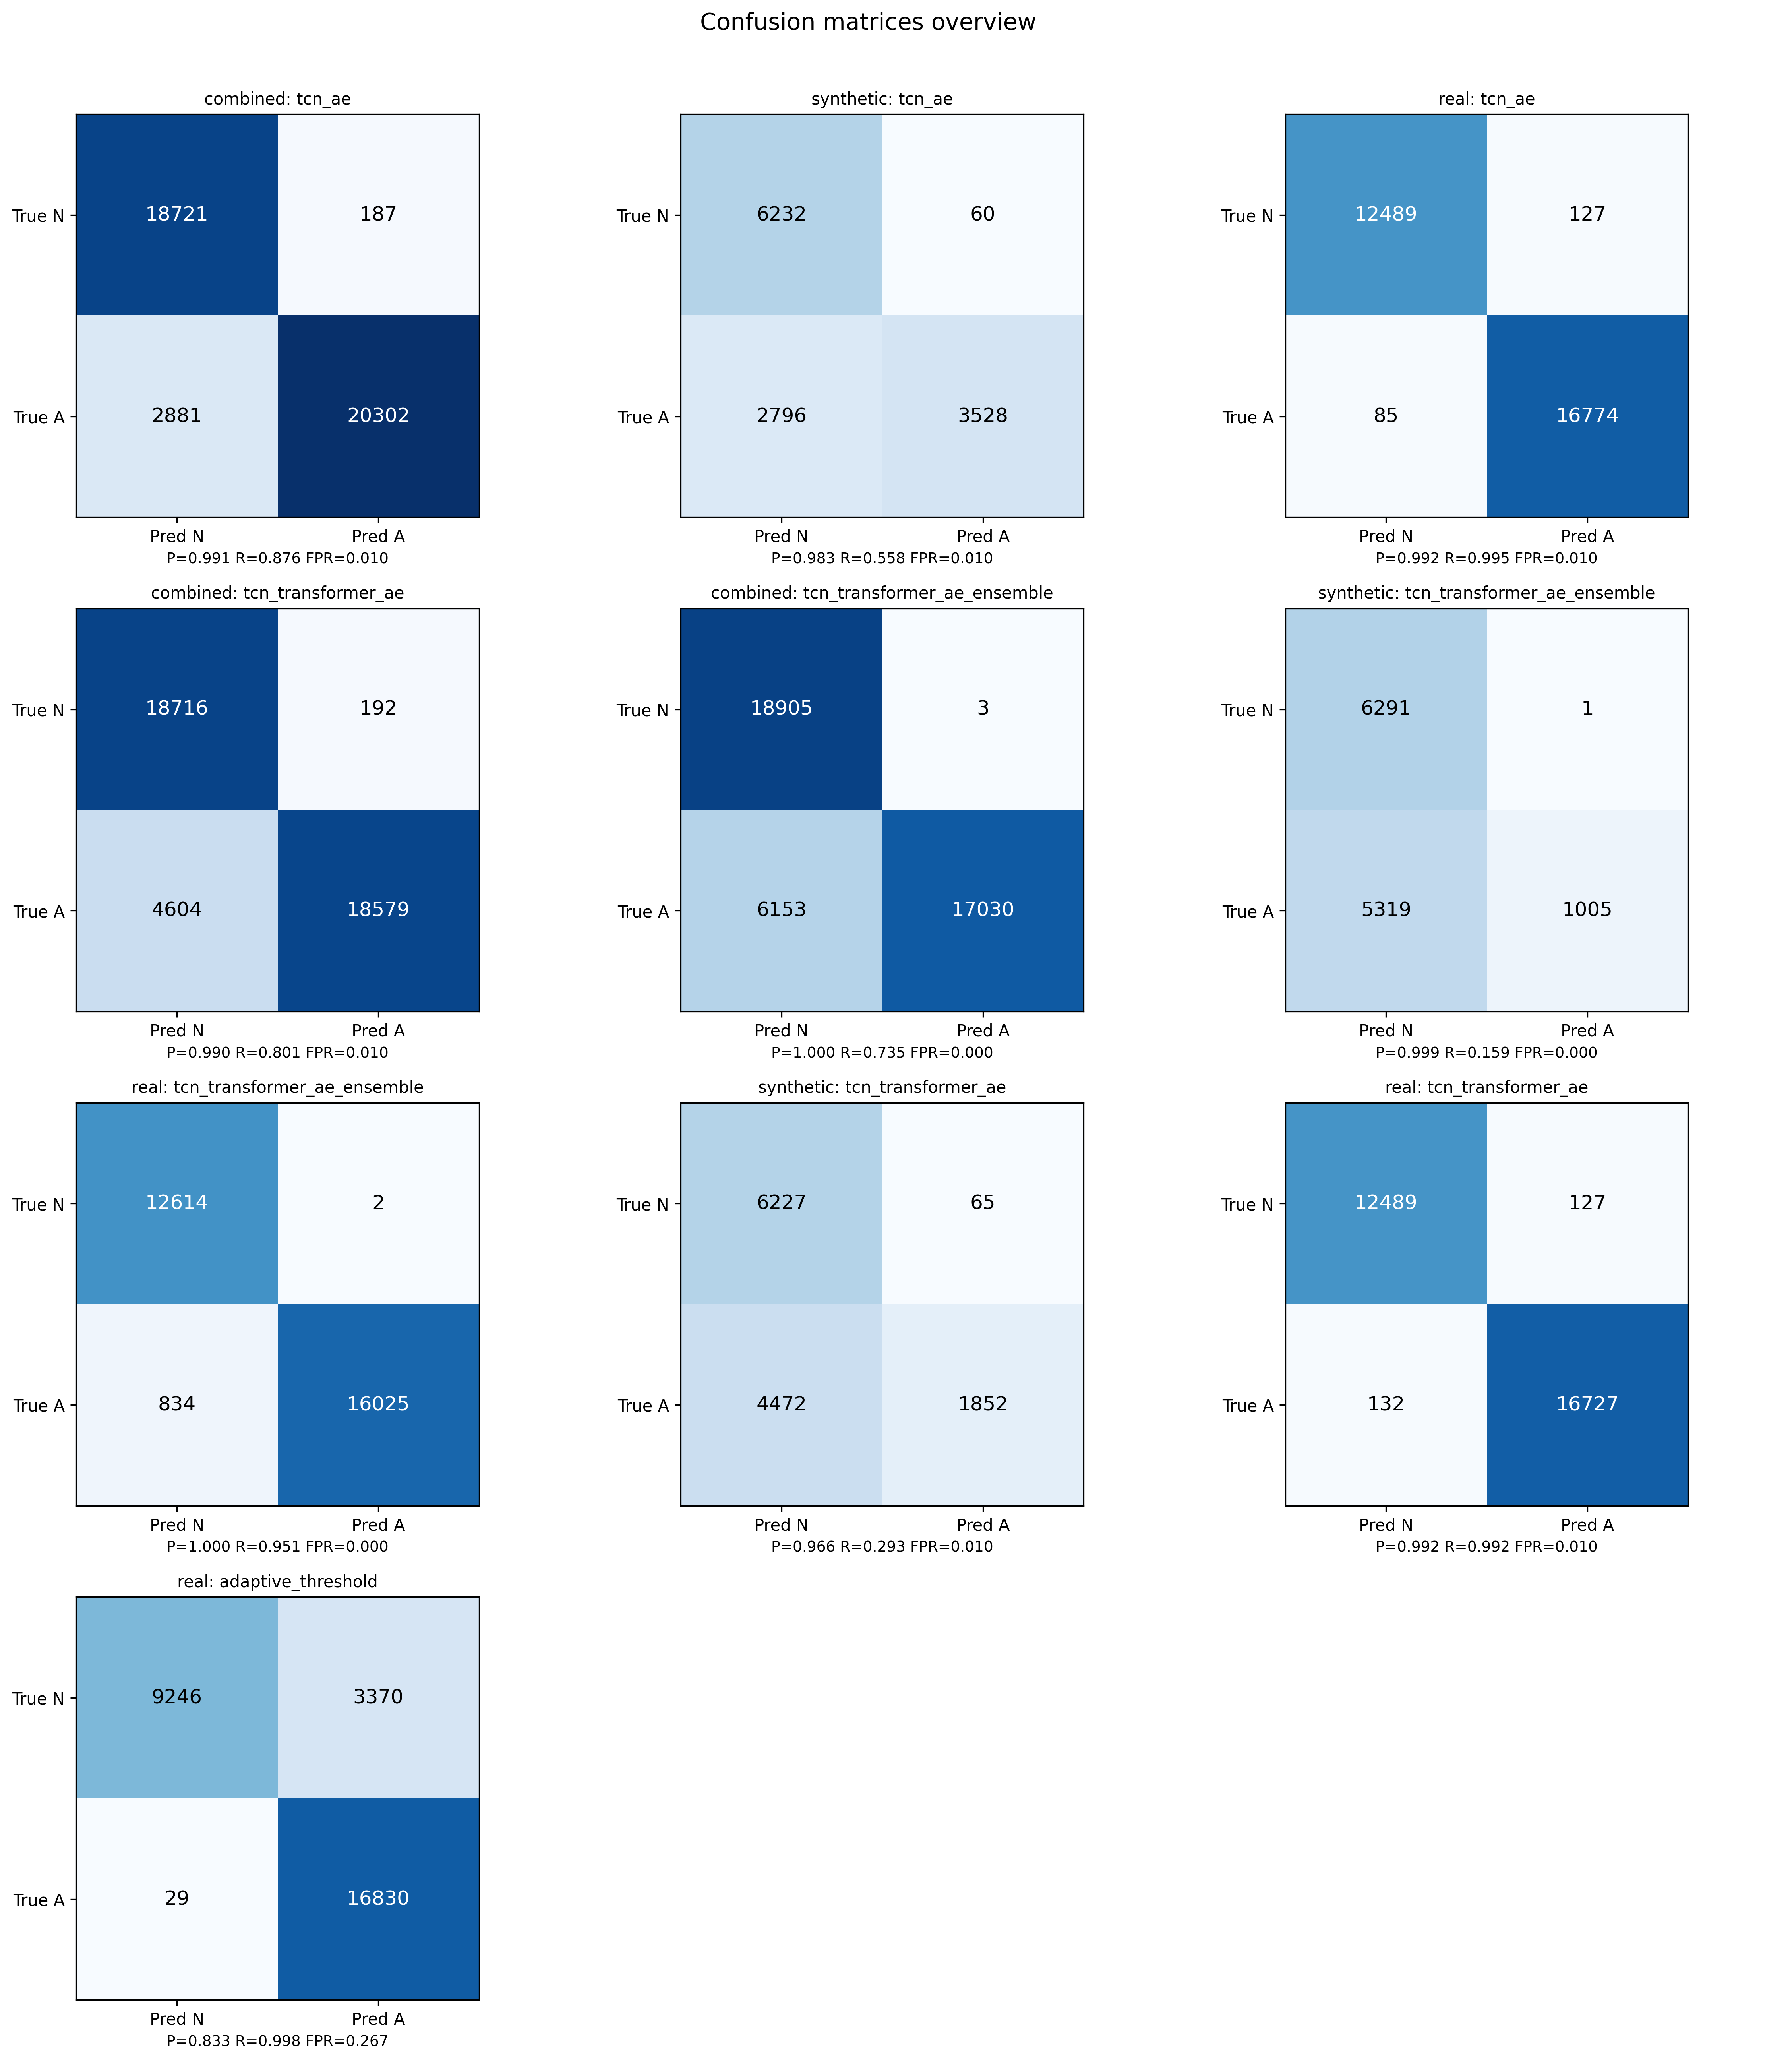

`confusion_matrix_adaptive_threshold_real.png`

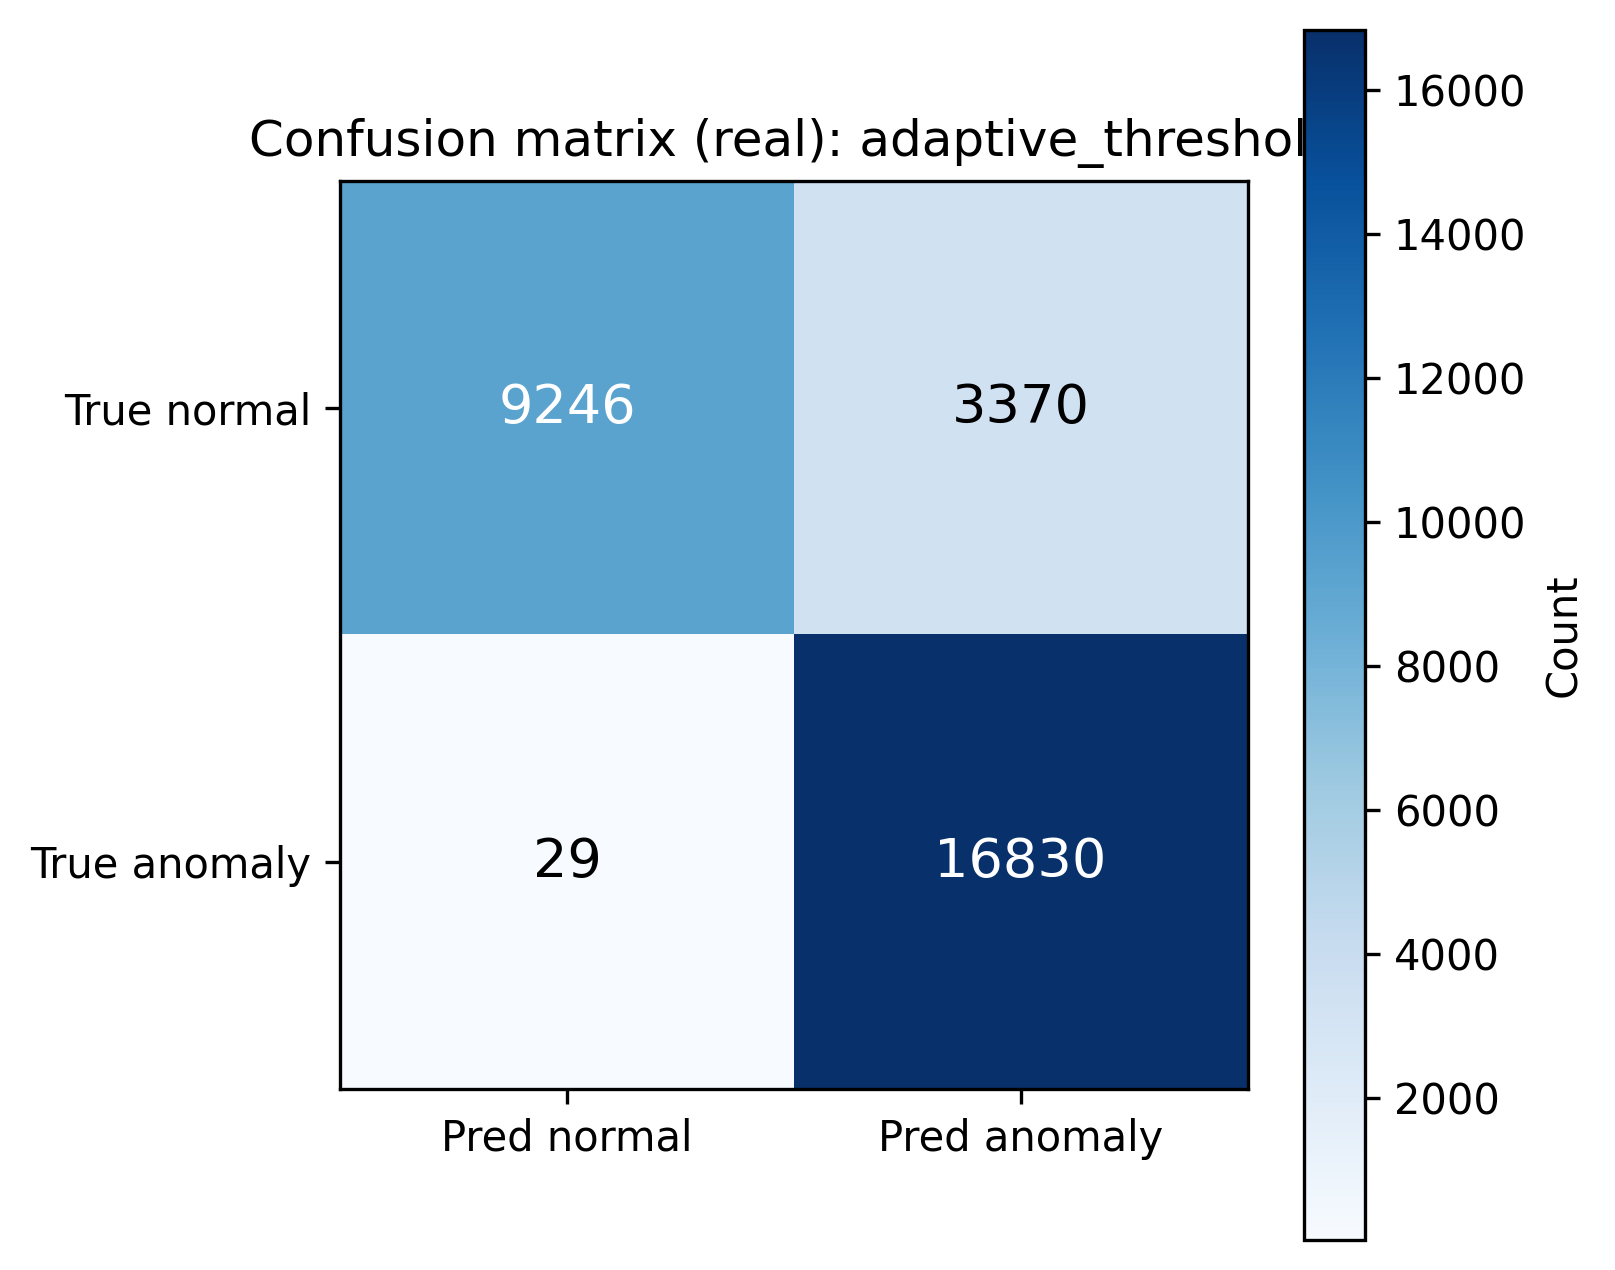

`confusion_matrix_tcn_ae_combined.png`

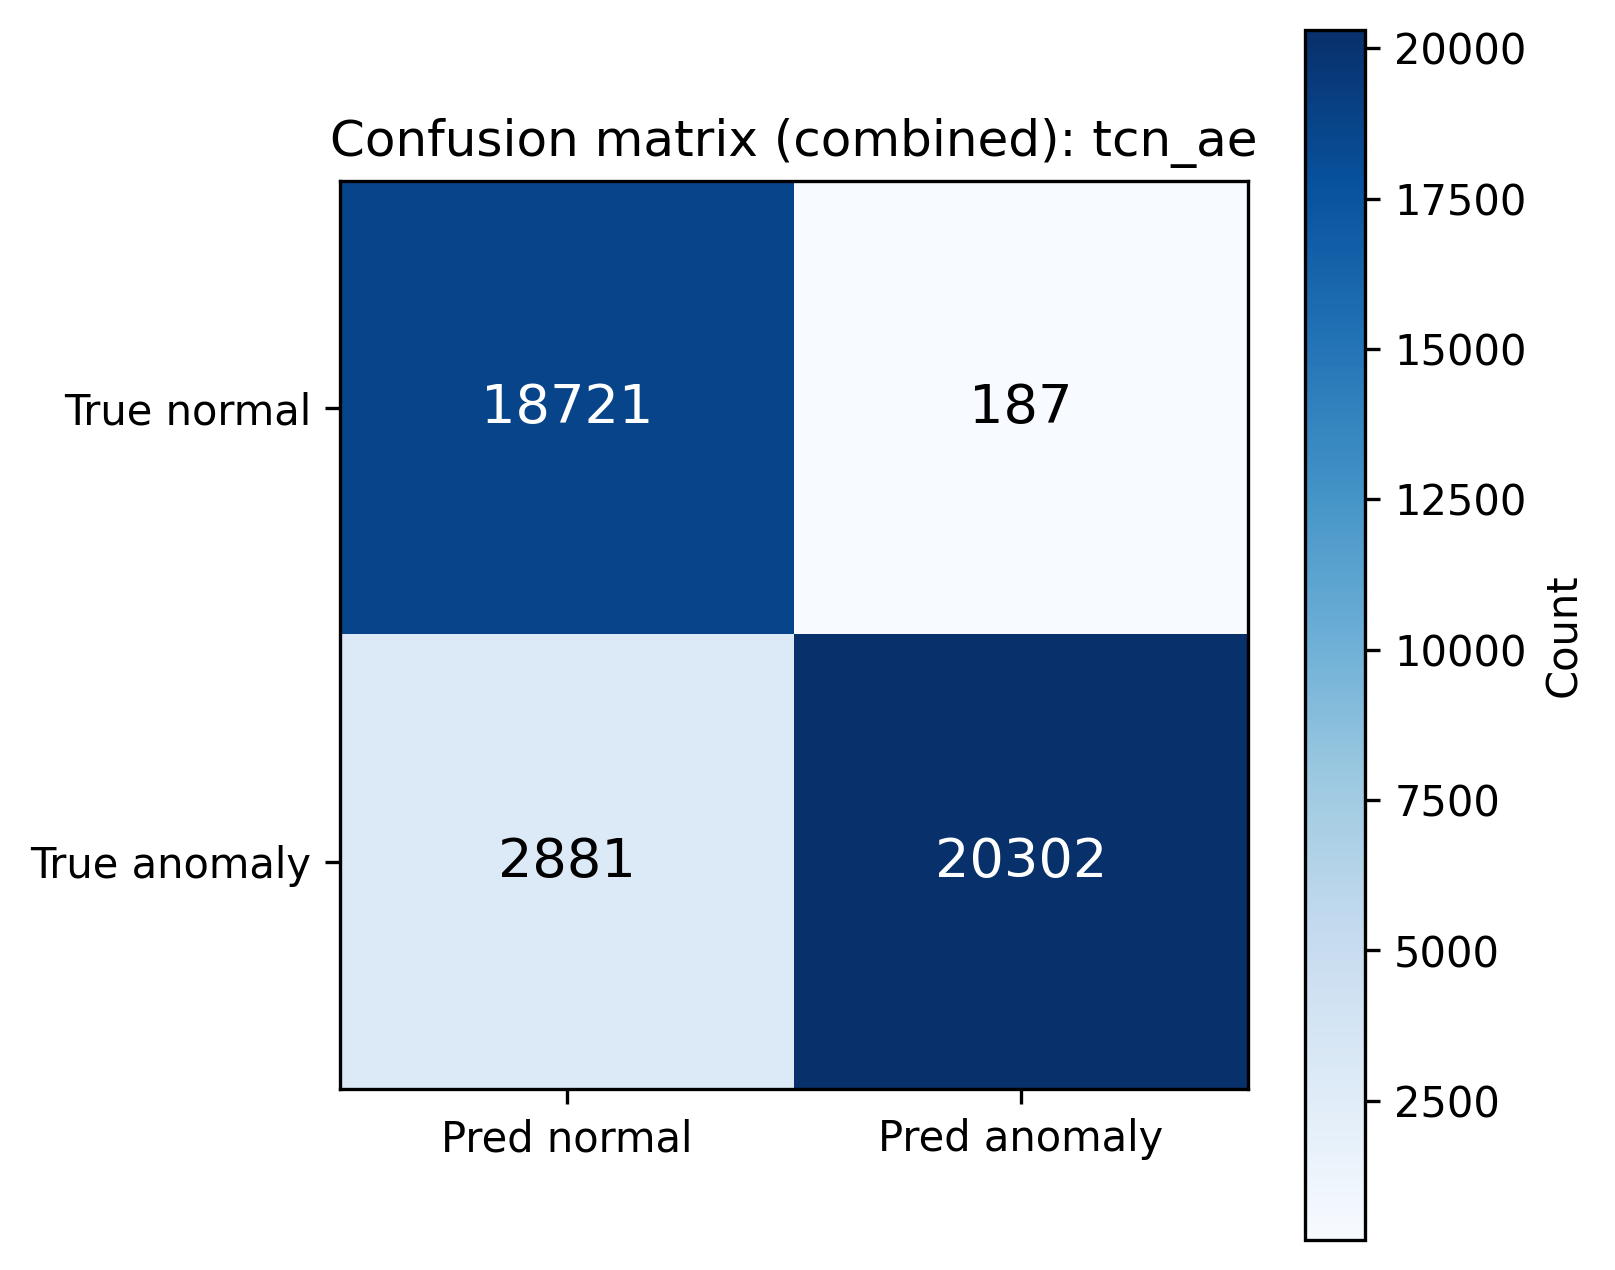

`confusion_matrix_tcn_ae_real.png`

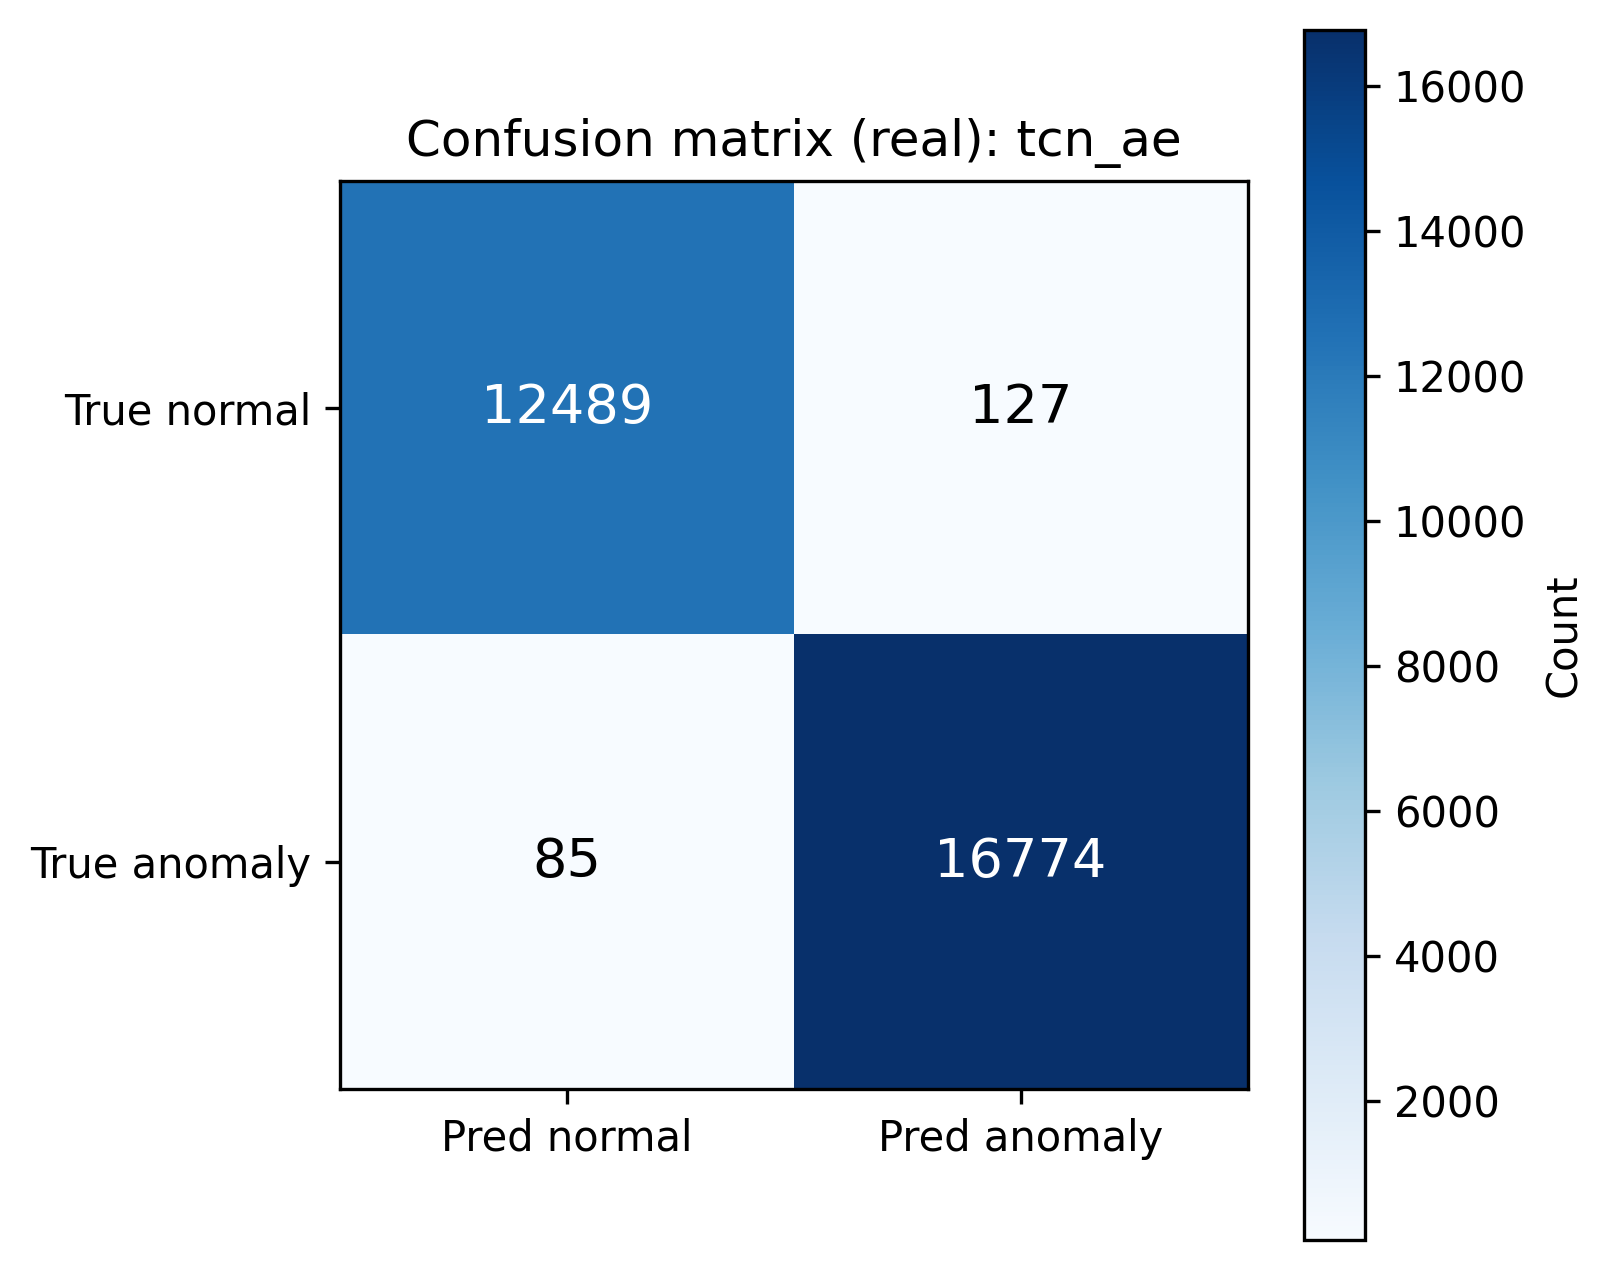

`confusion_matrix_tcn_ae_synthetic.png`

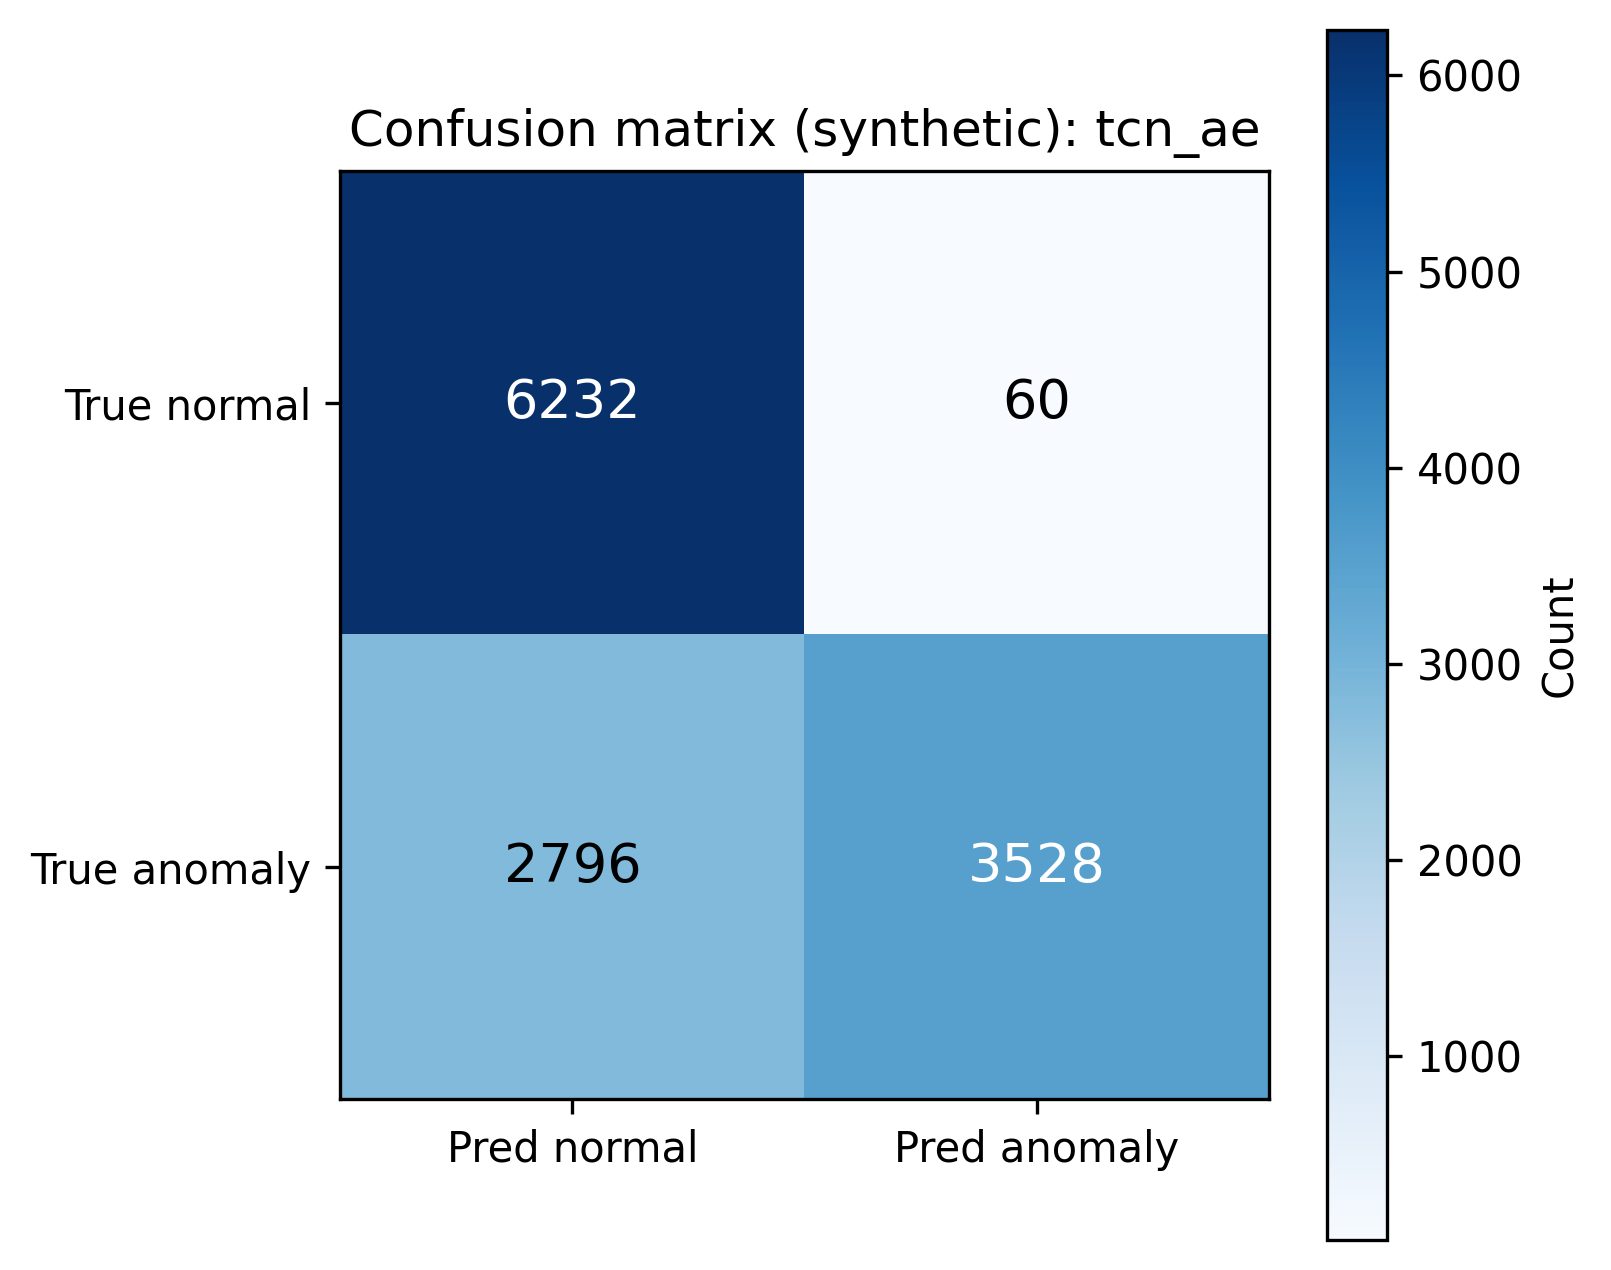

`confusion_matrix_tcn_transformer_ae_combined.png`

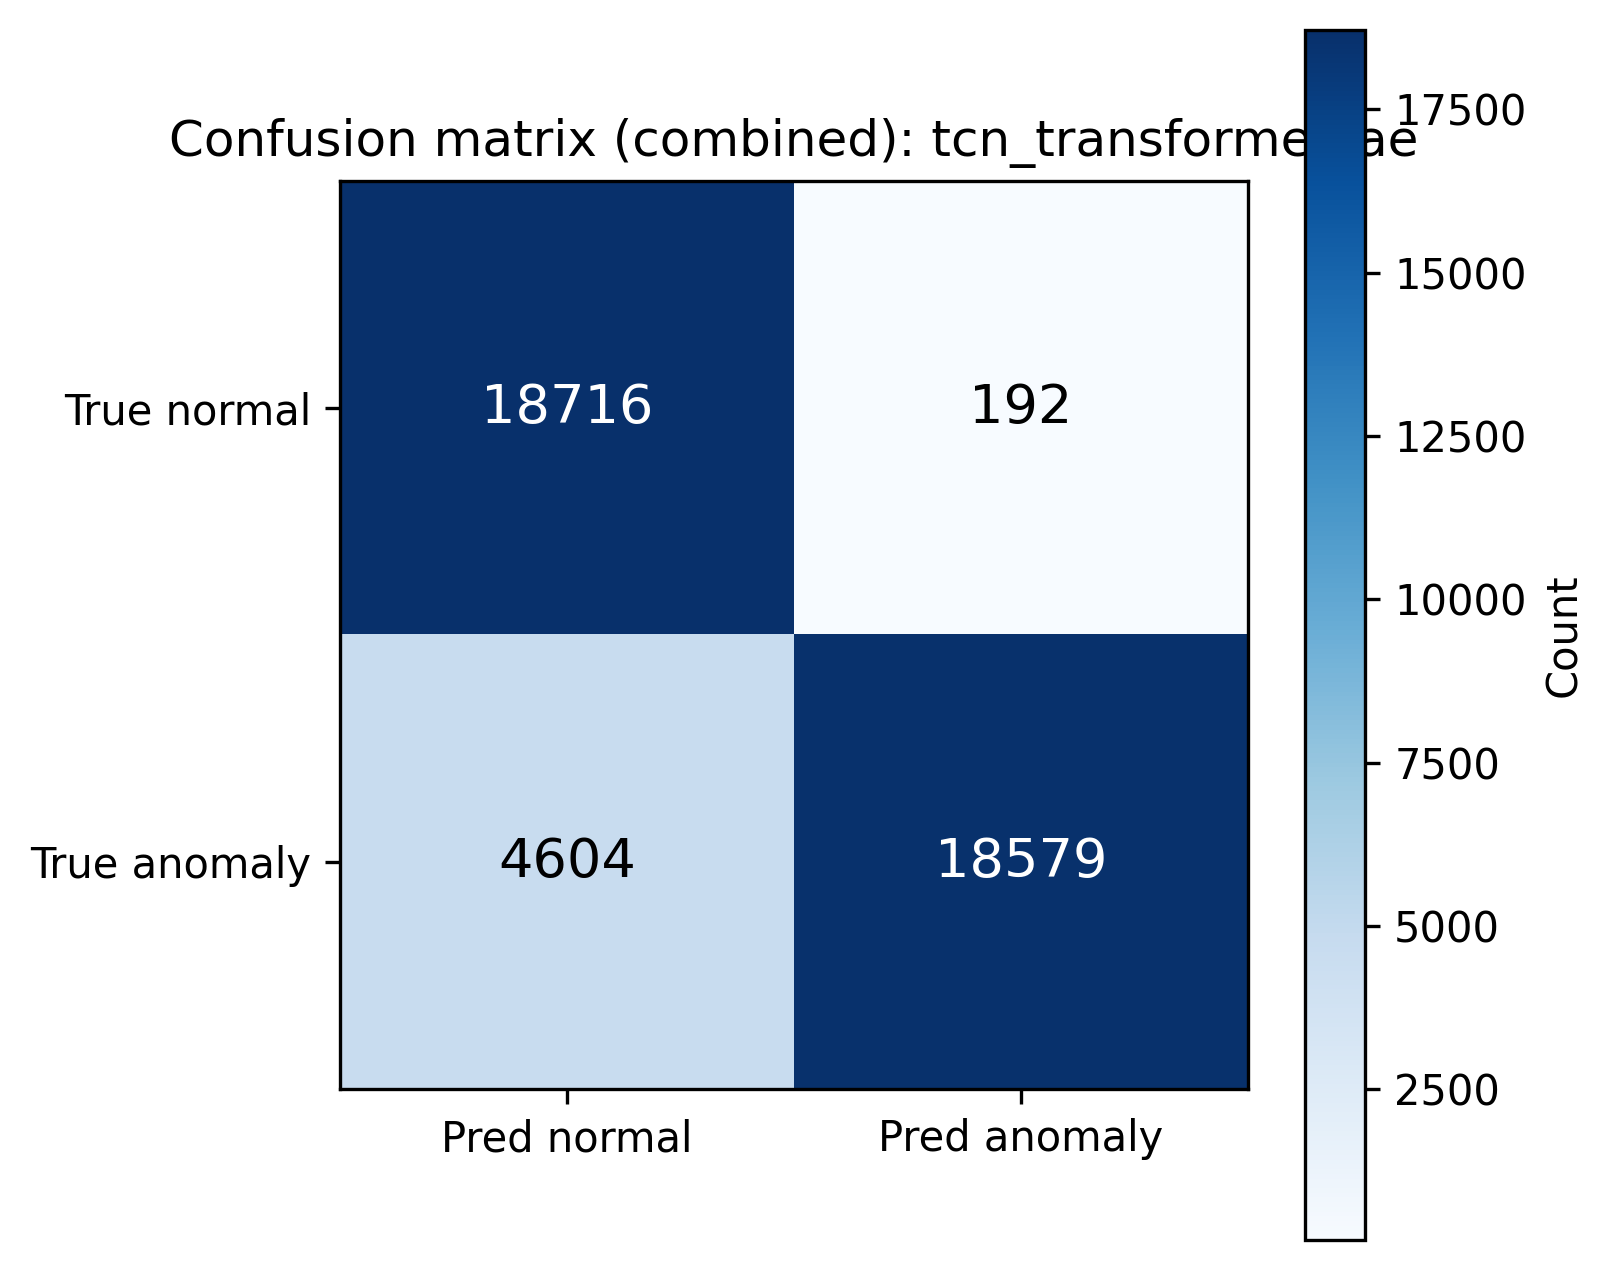

`confusion_matrix_tcn_transformer_ae_ensemble_combined.png`

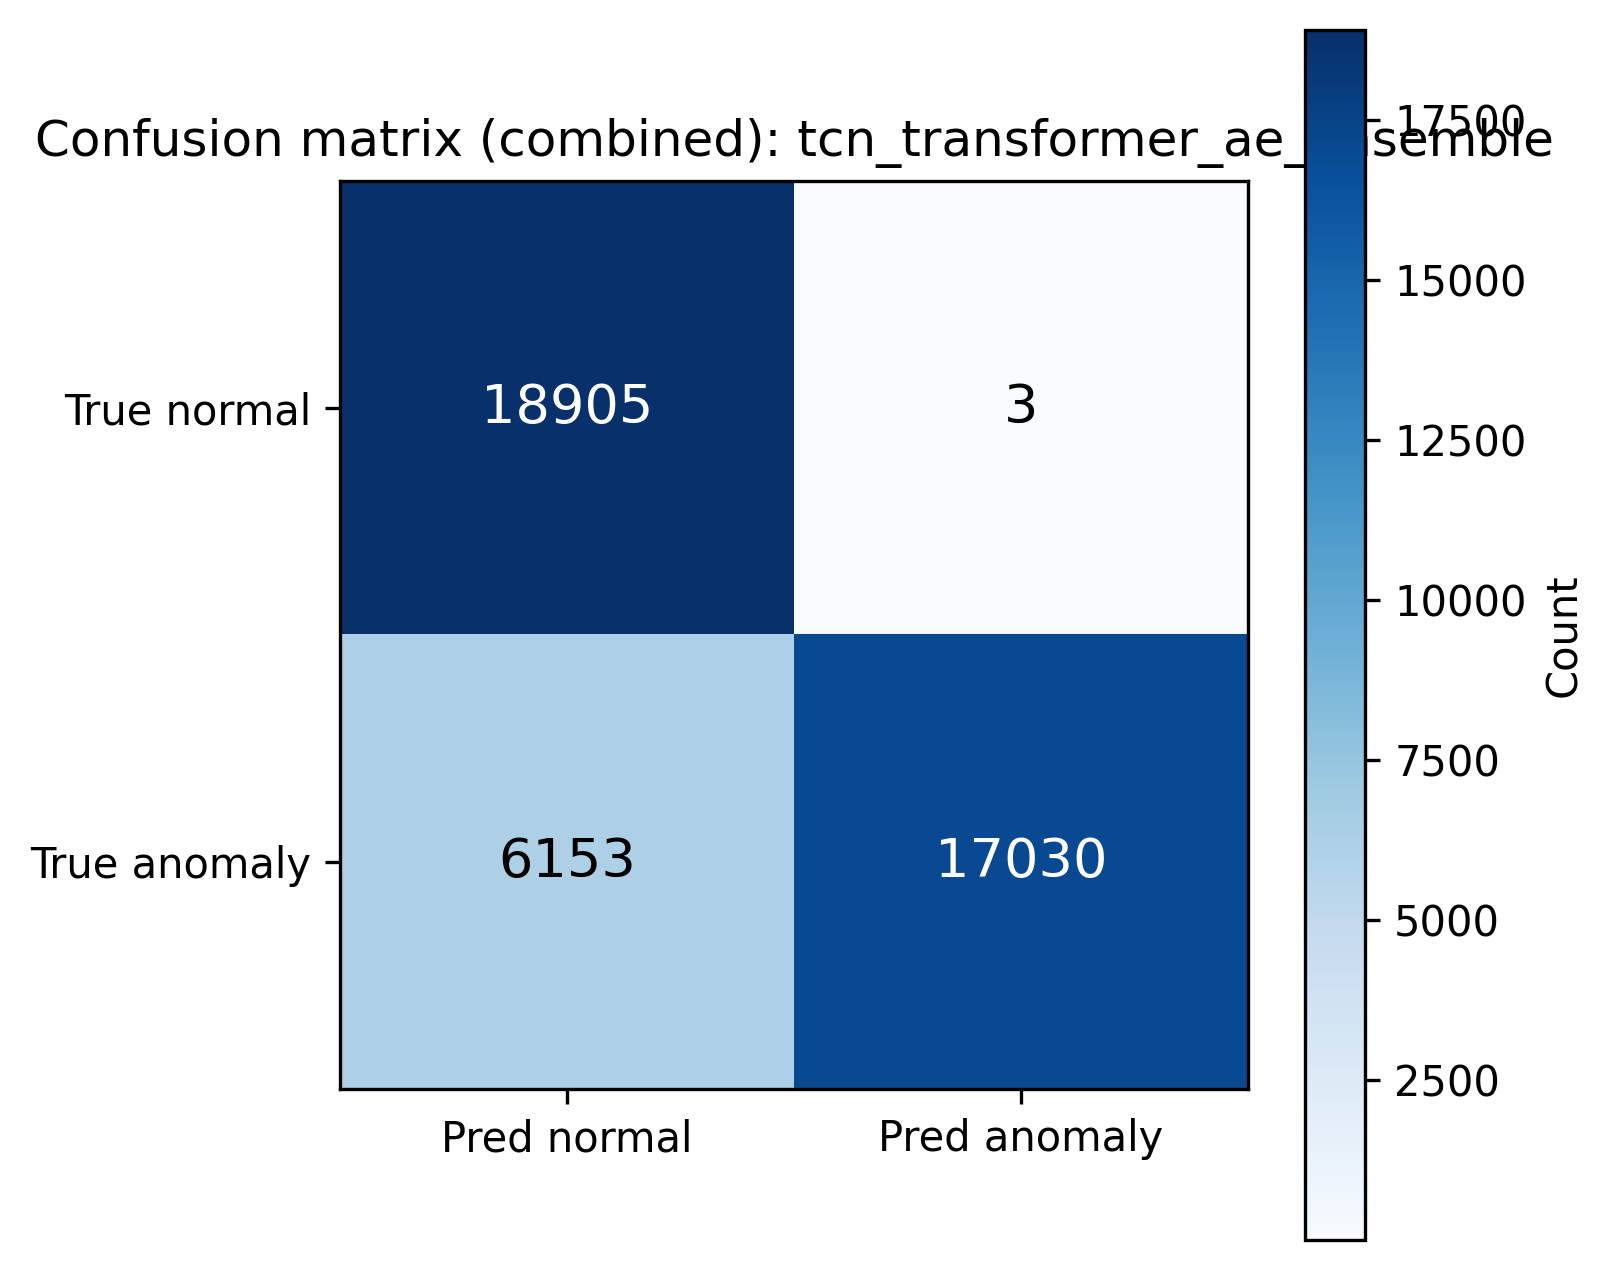

`confusion_matrix_tcn_transformer_ae_ensemble_real.png`

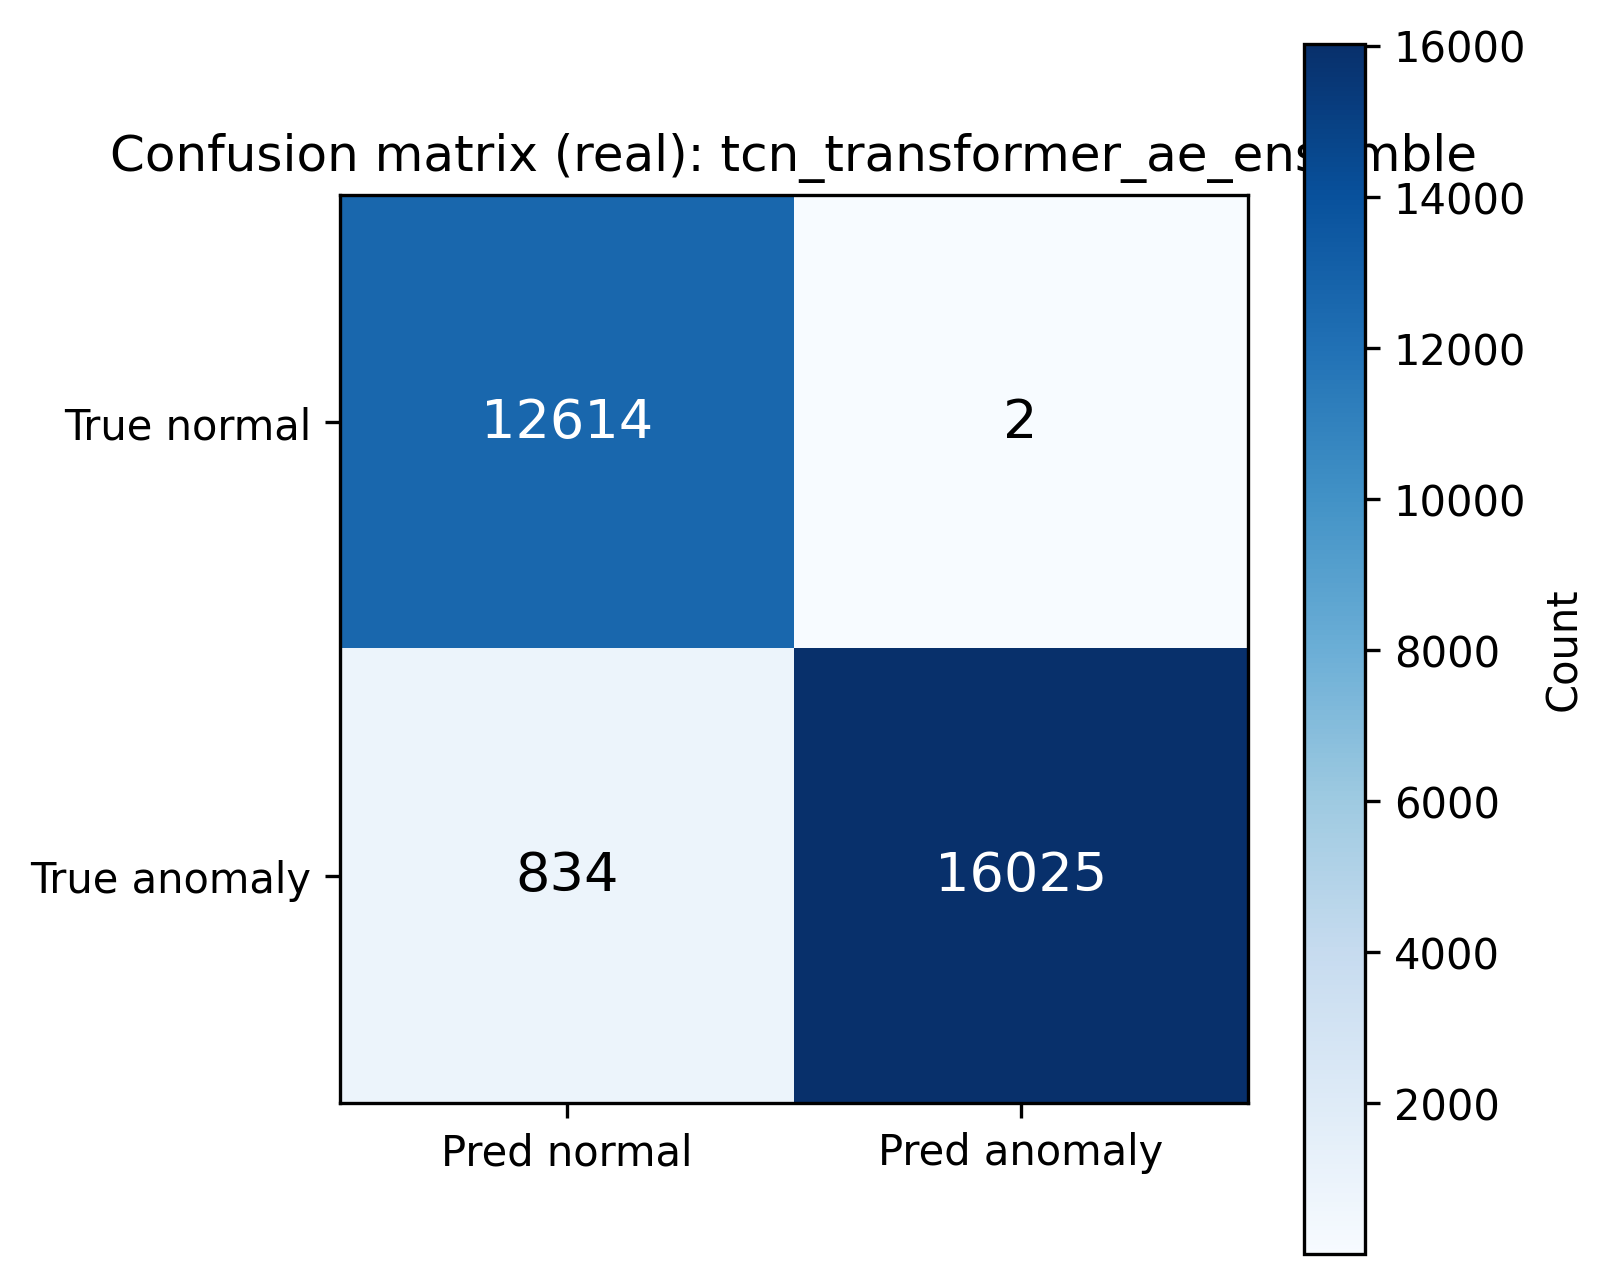

`confusion_matrix_tcn_transformer_ae_ensemble_synthetic.png`

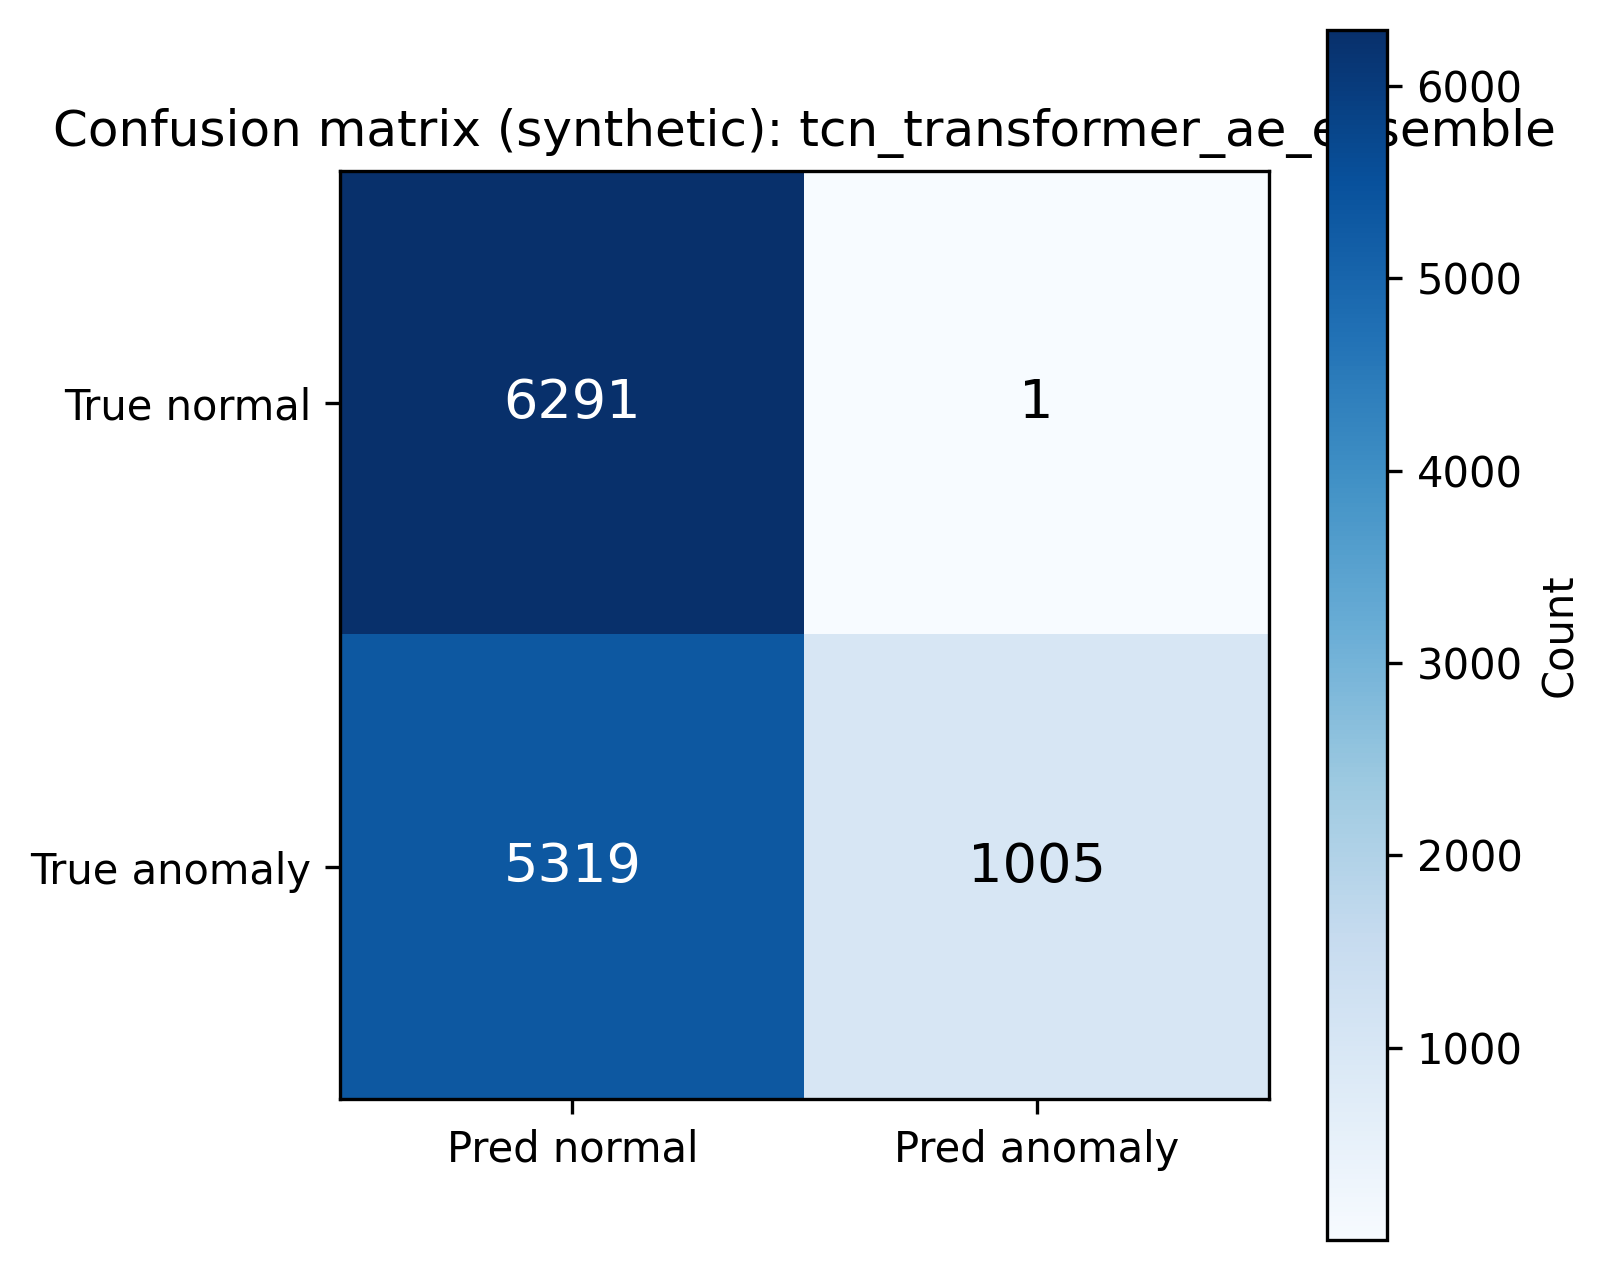

`confusion_matrix_tcn_transformer_ae_real.png`

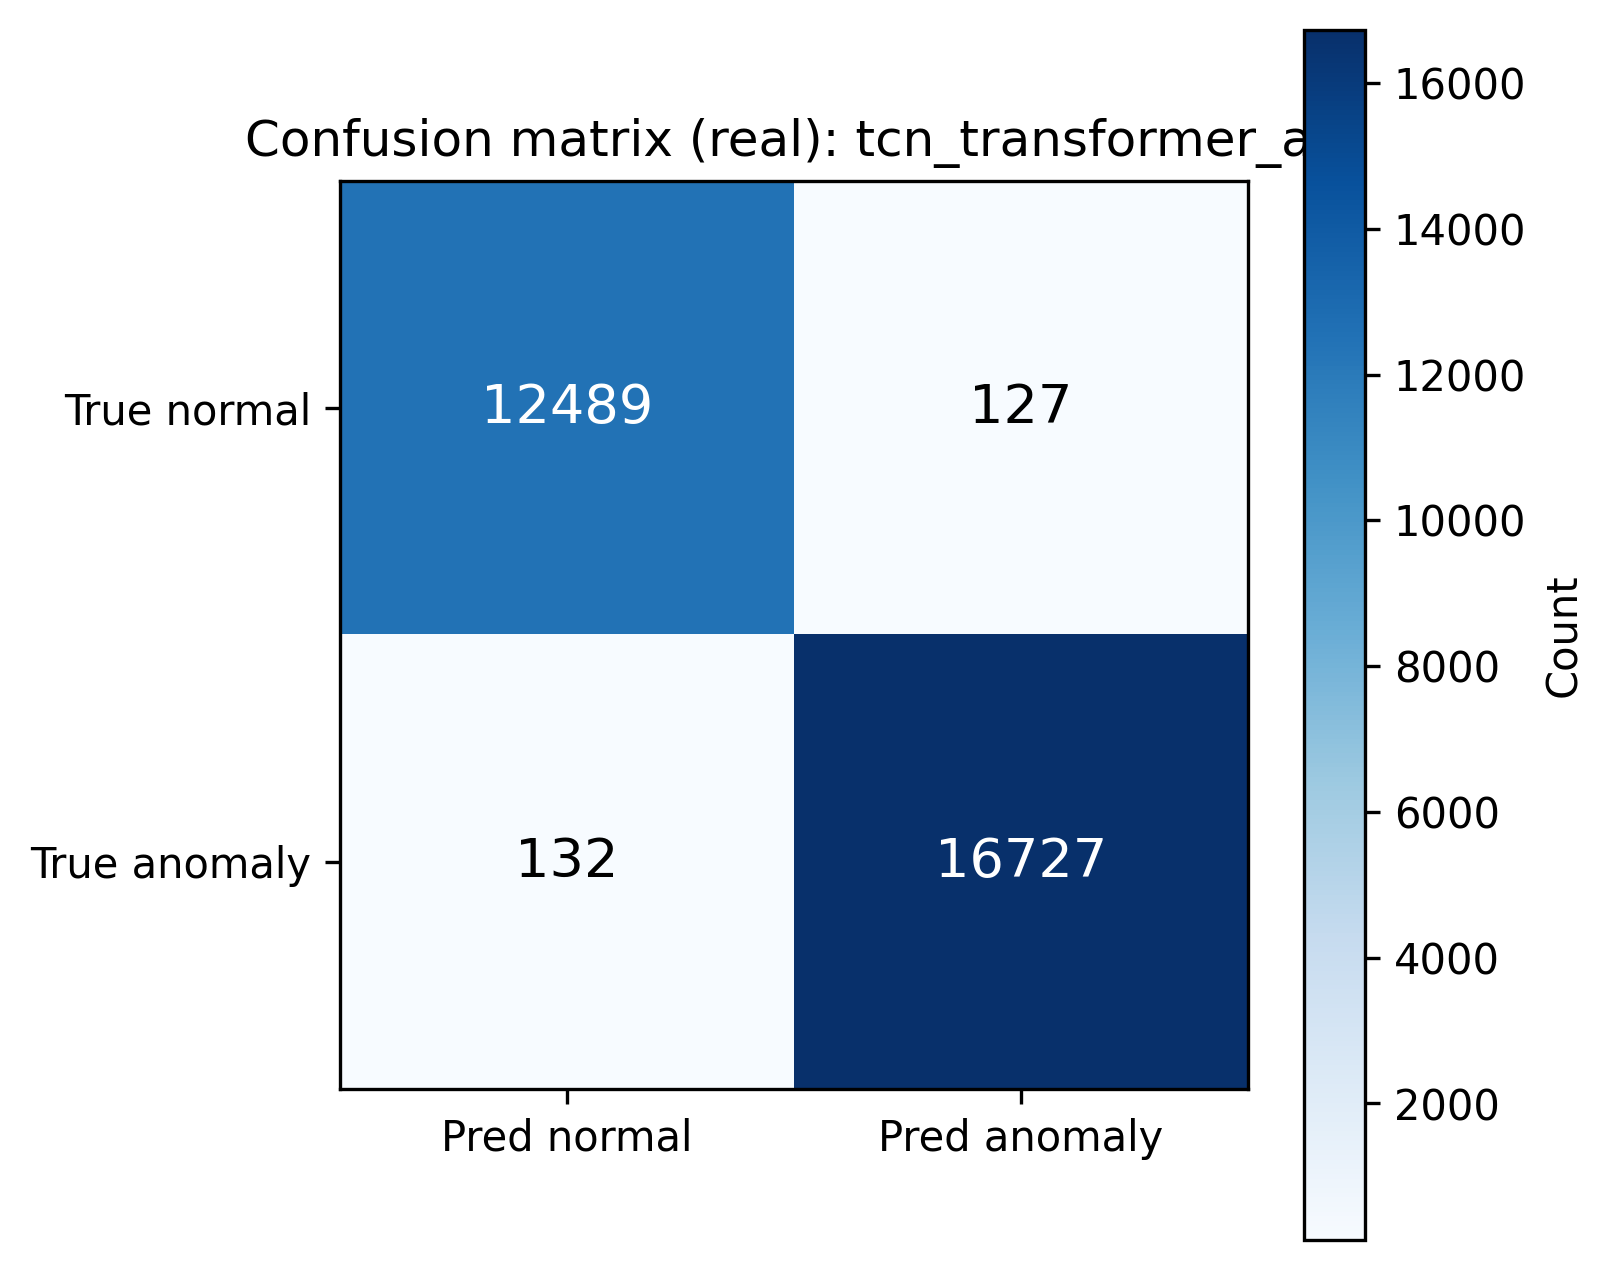

`confusion_matrix_tcn_transformer_ae_synthetic.png`

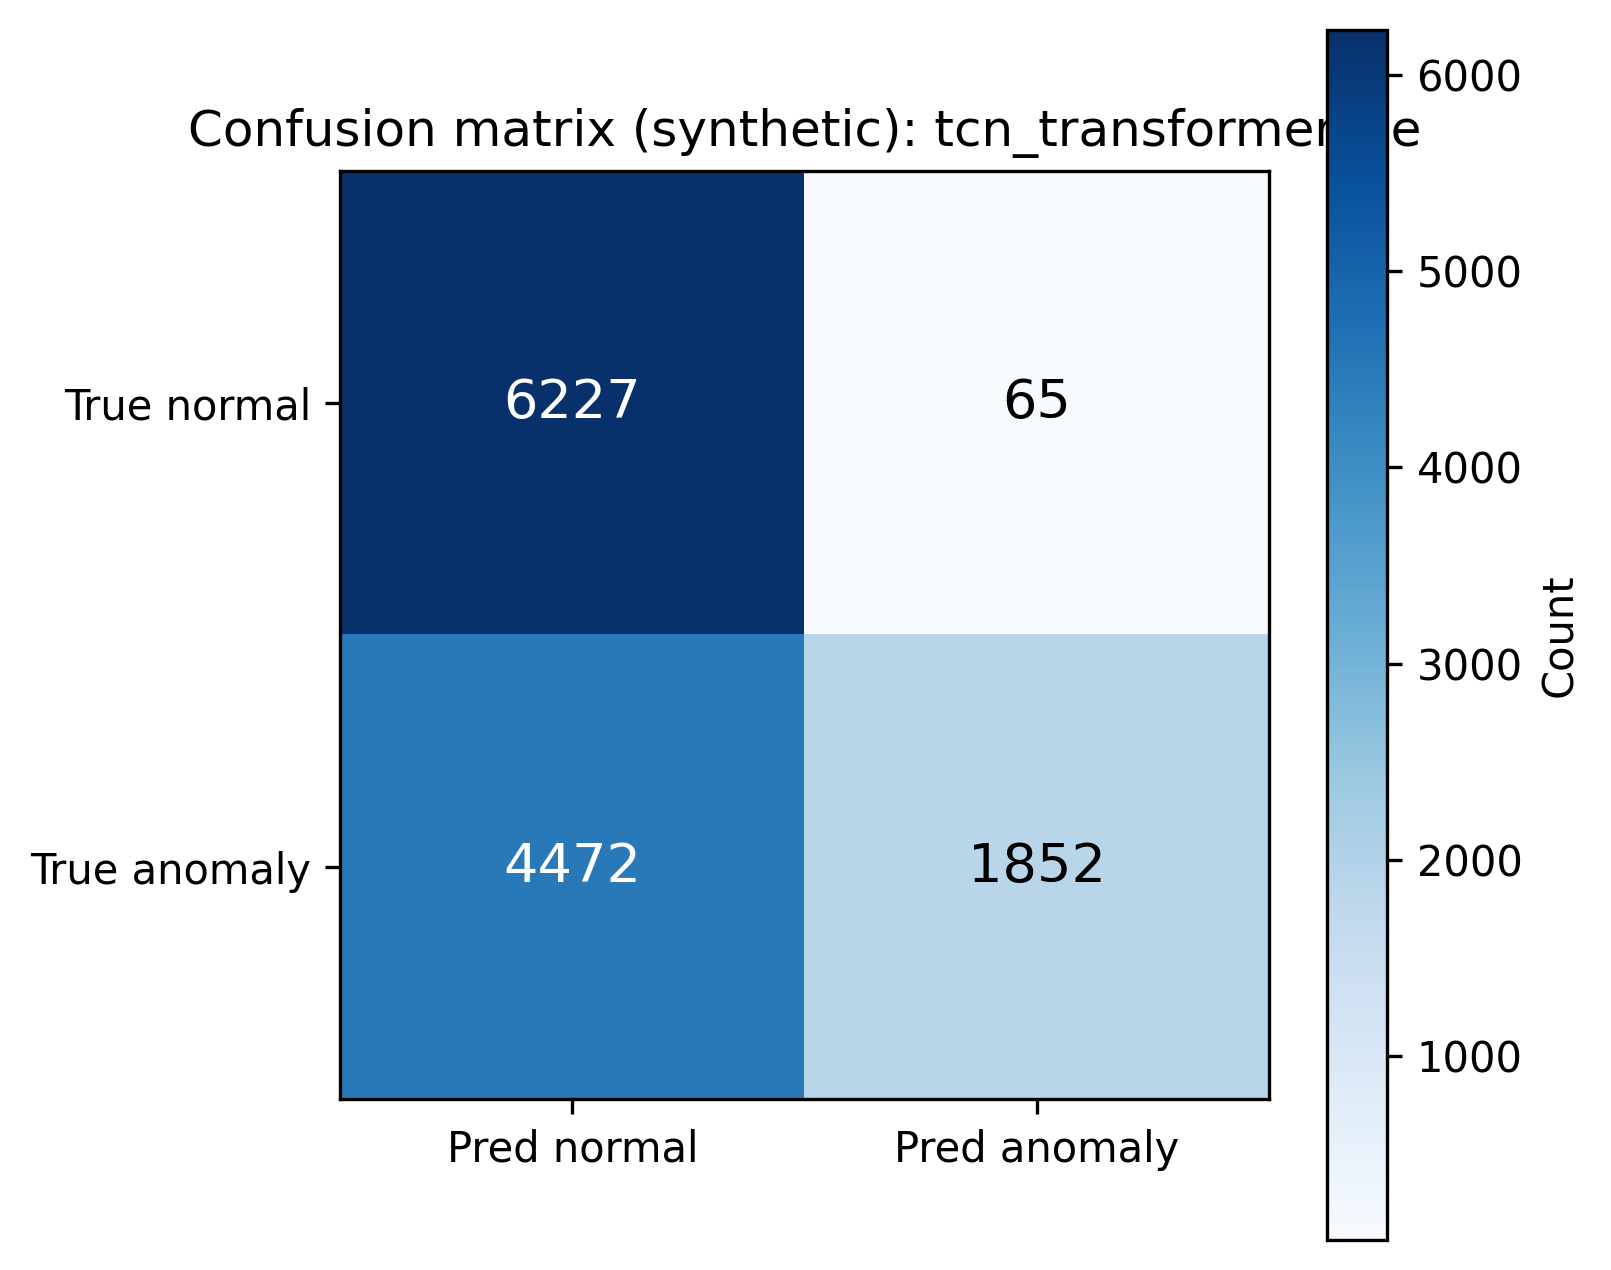

**Общие heatmap**

`aggregate_heatmap_tcn_ae_reconstruction.png`

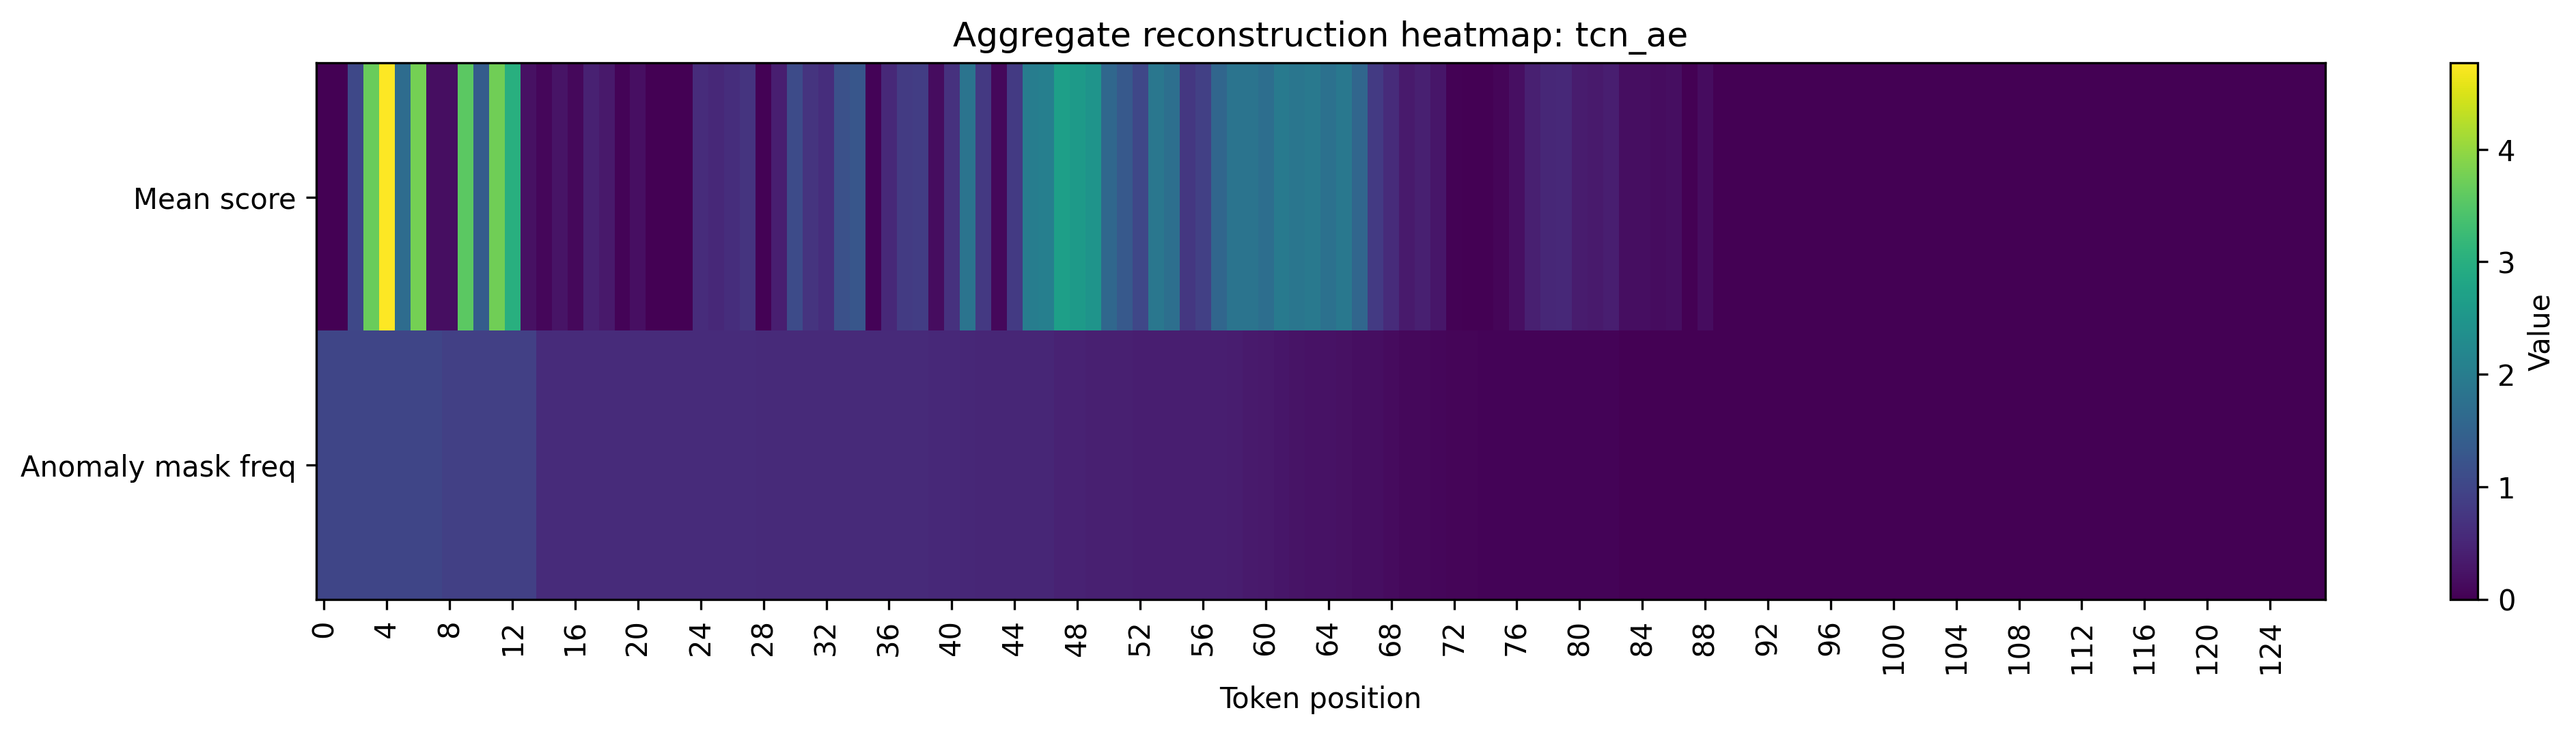

`aggregate_heatmap_tcn_transformer_ae_attention.png`

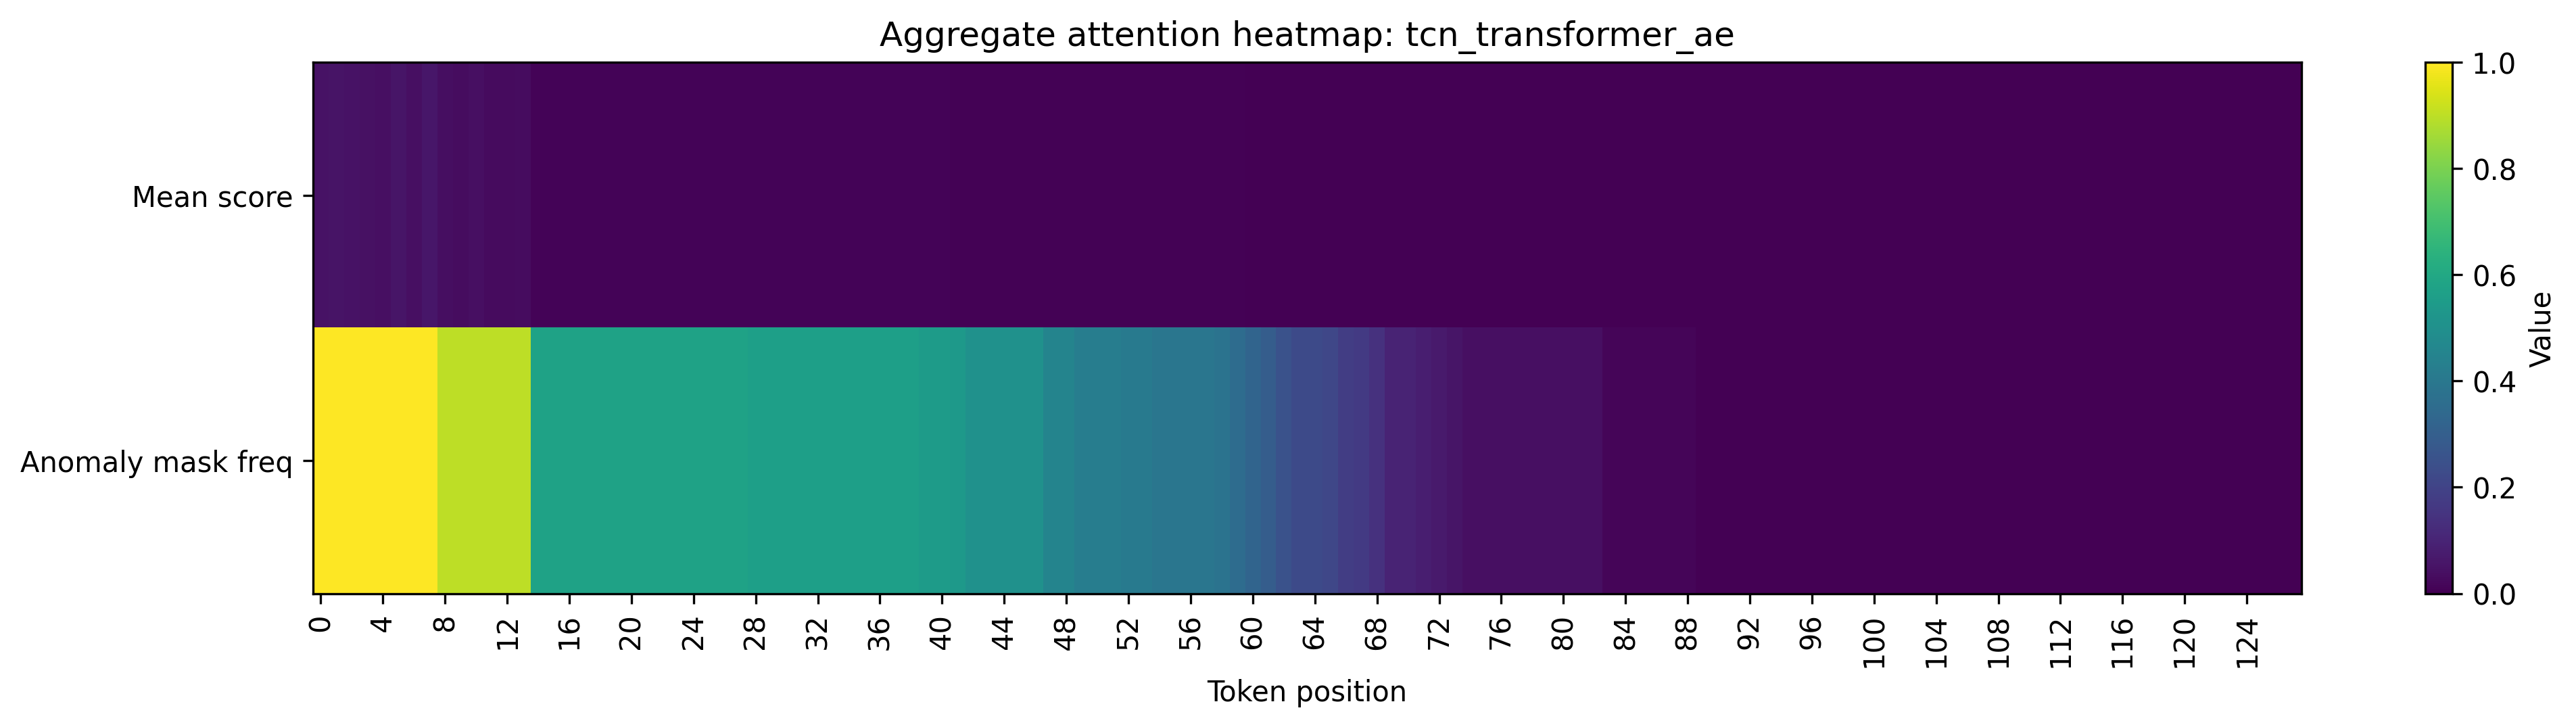

`aggregate_heatmap_tcn_transformer_ae_ensemble_attention.png`

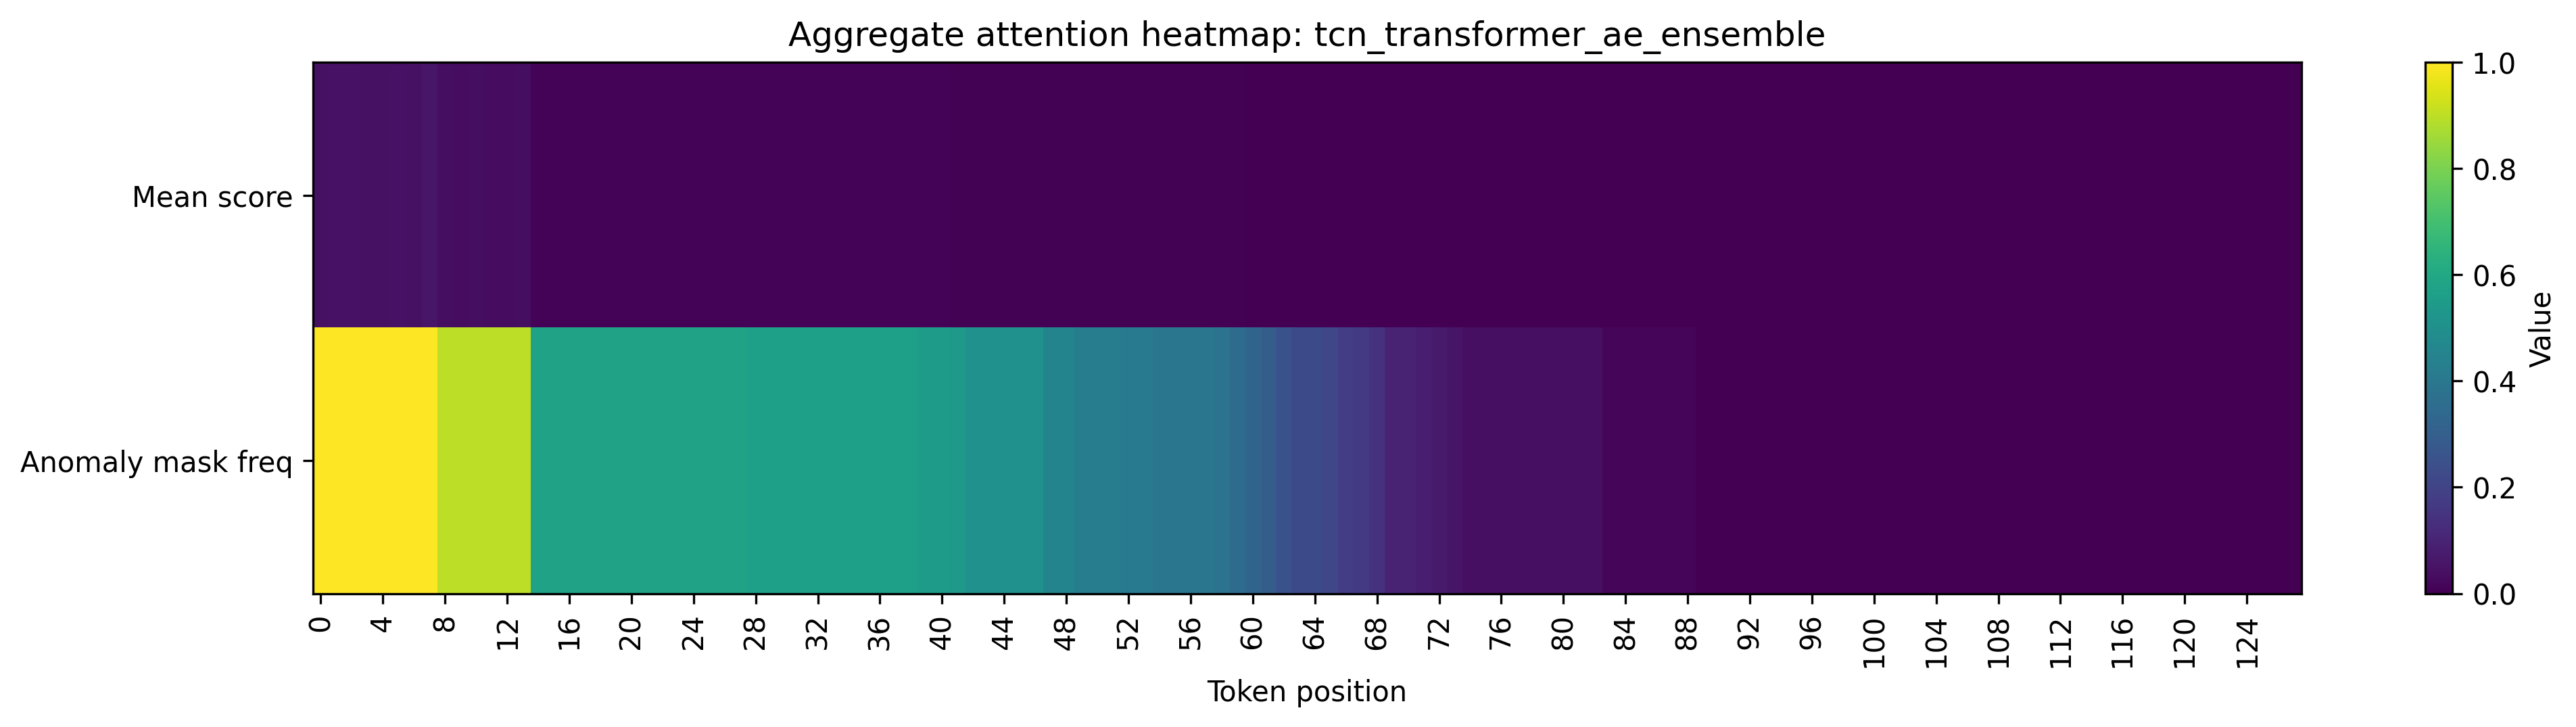

`aggregate_heatmap_tcn_transformer_ae_reconstruction.png`

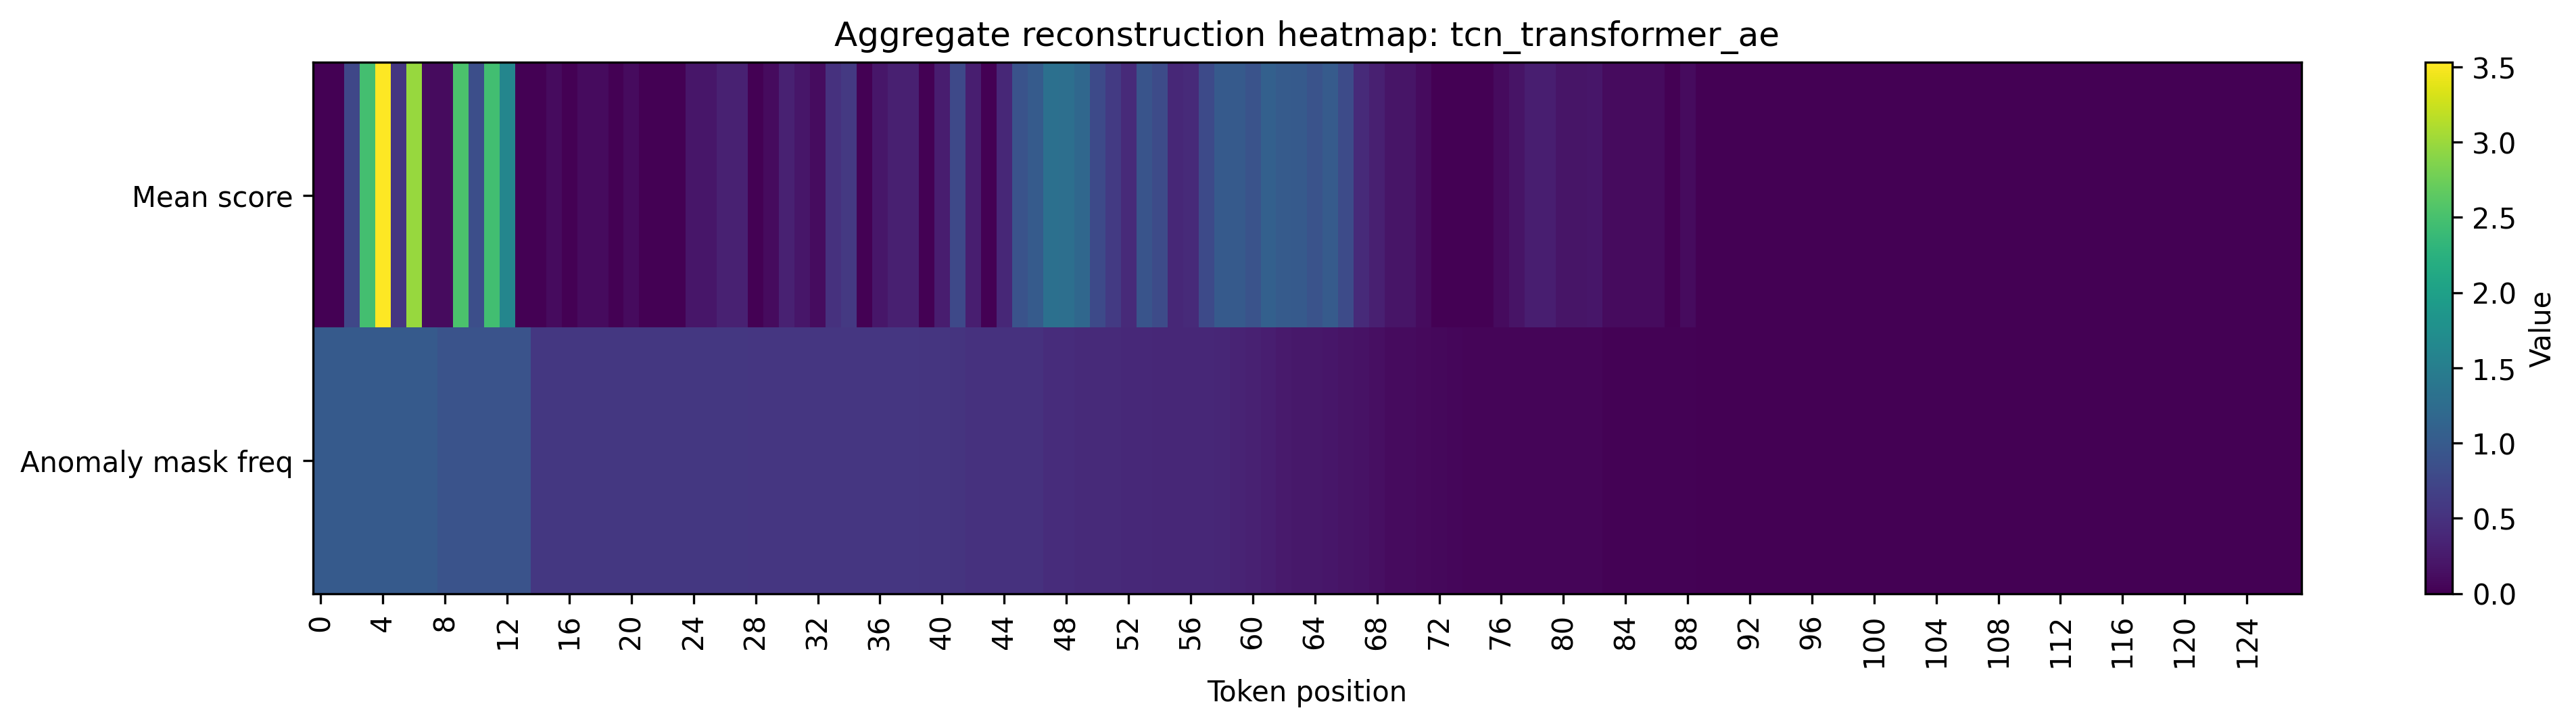

### rcaeval_reconstruction_v3

**Матрицы ошибок**

`confusion_matrices_overview.png`

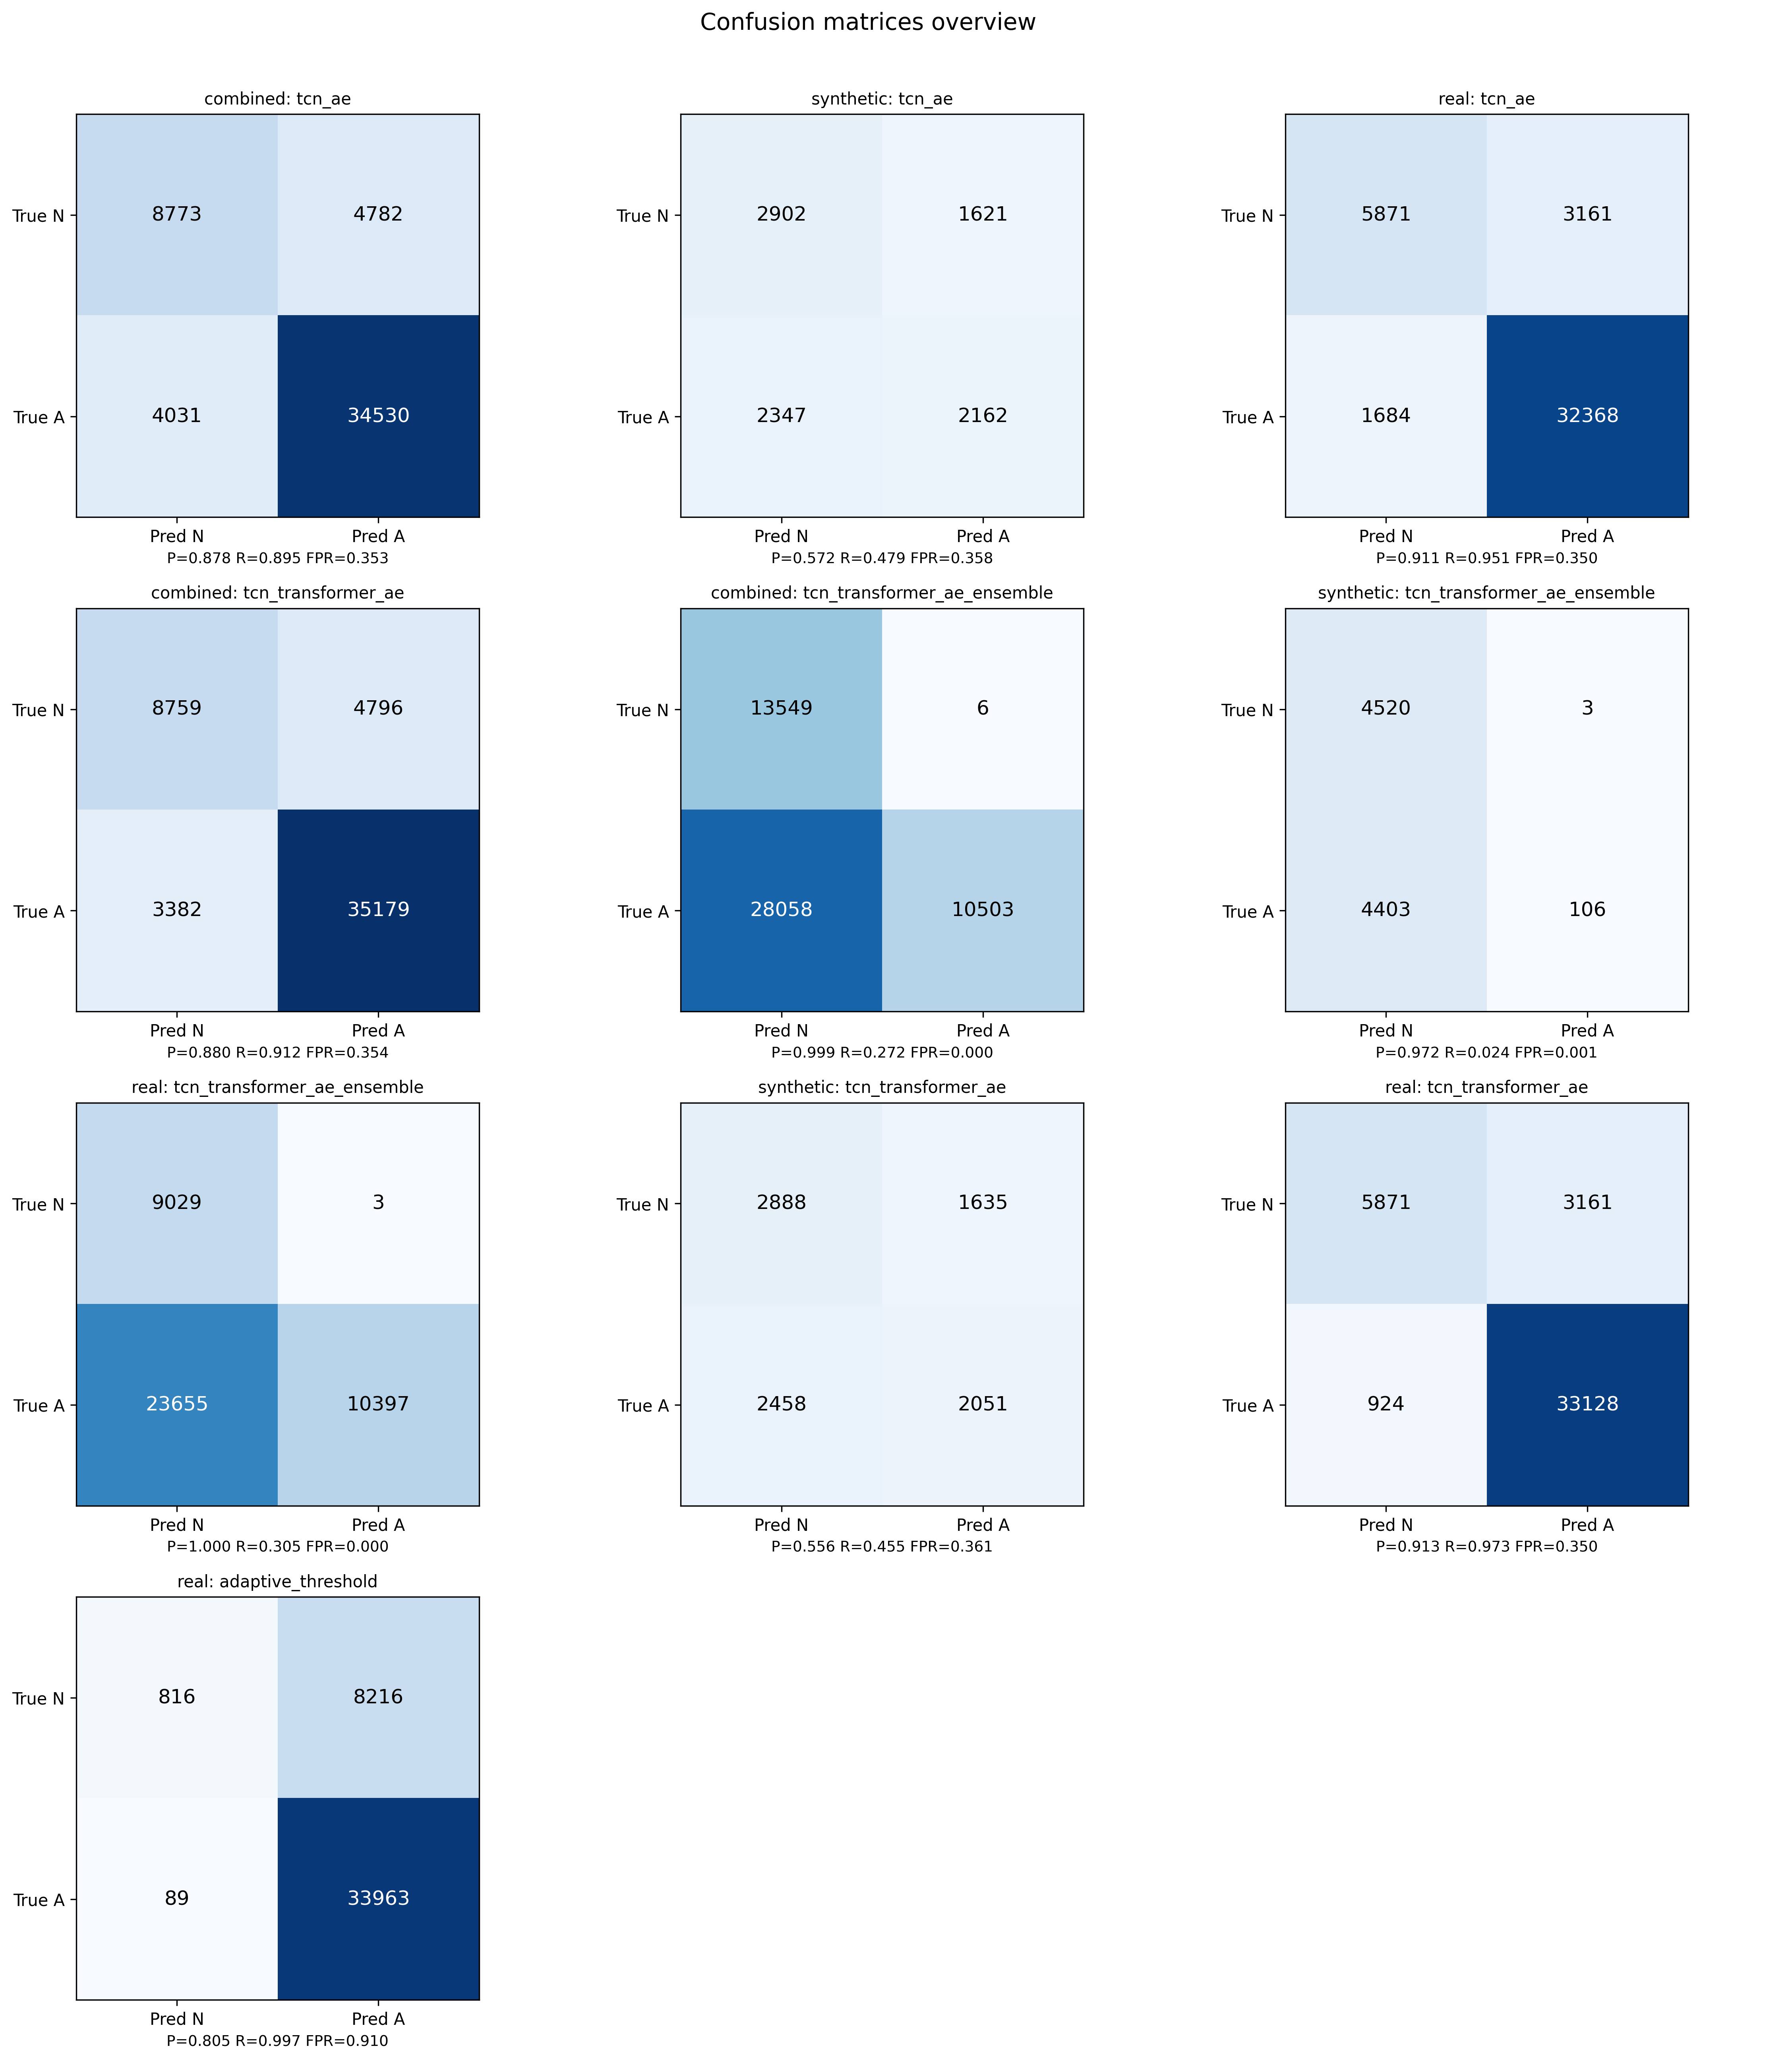

`confusion_matrix_adaptive_threshold_real.png`

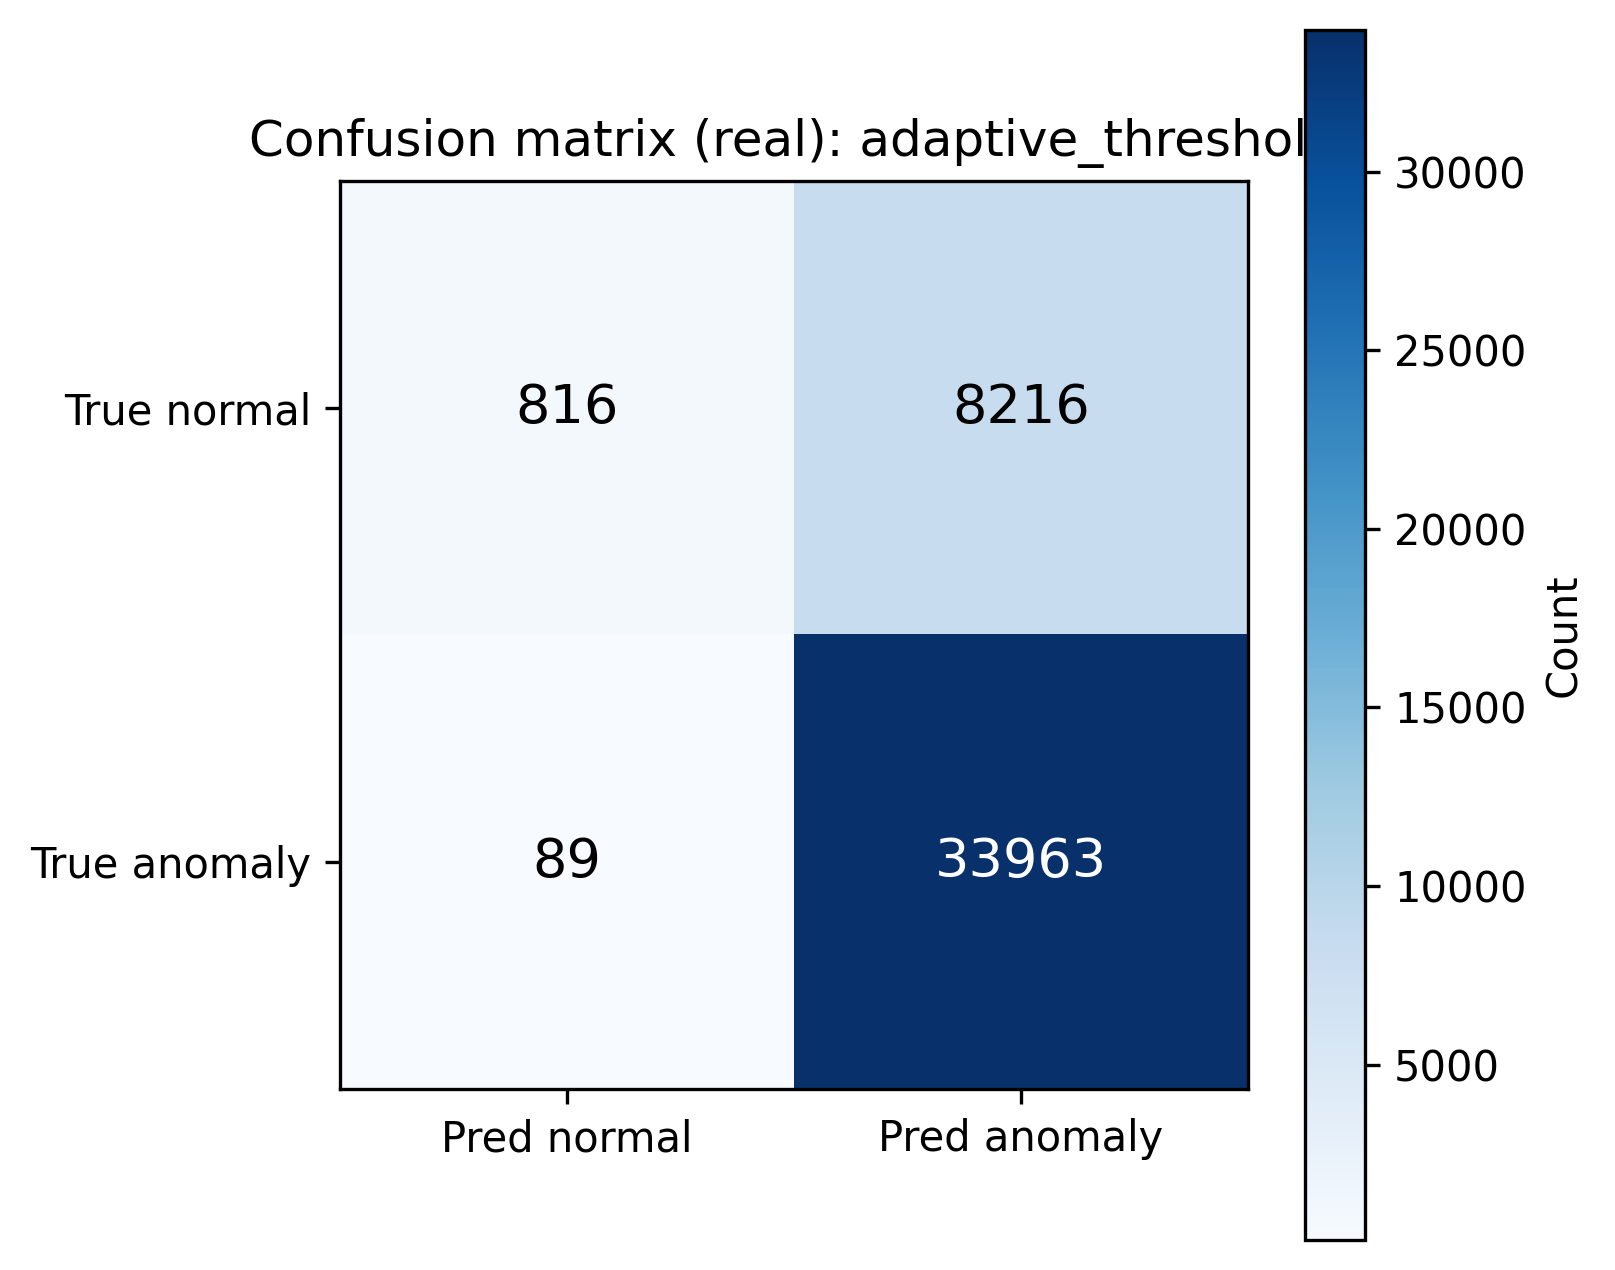

`confusion_matrix_tcn_ae_combined.png`

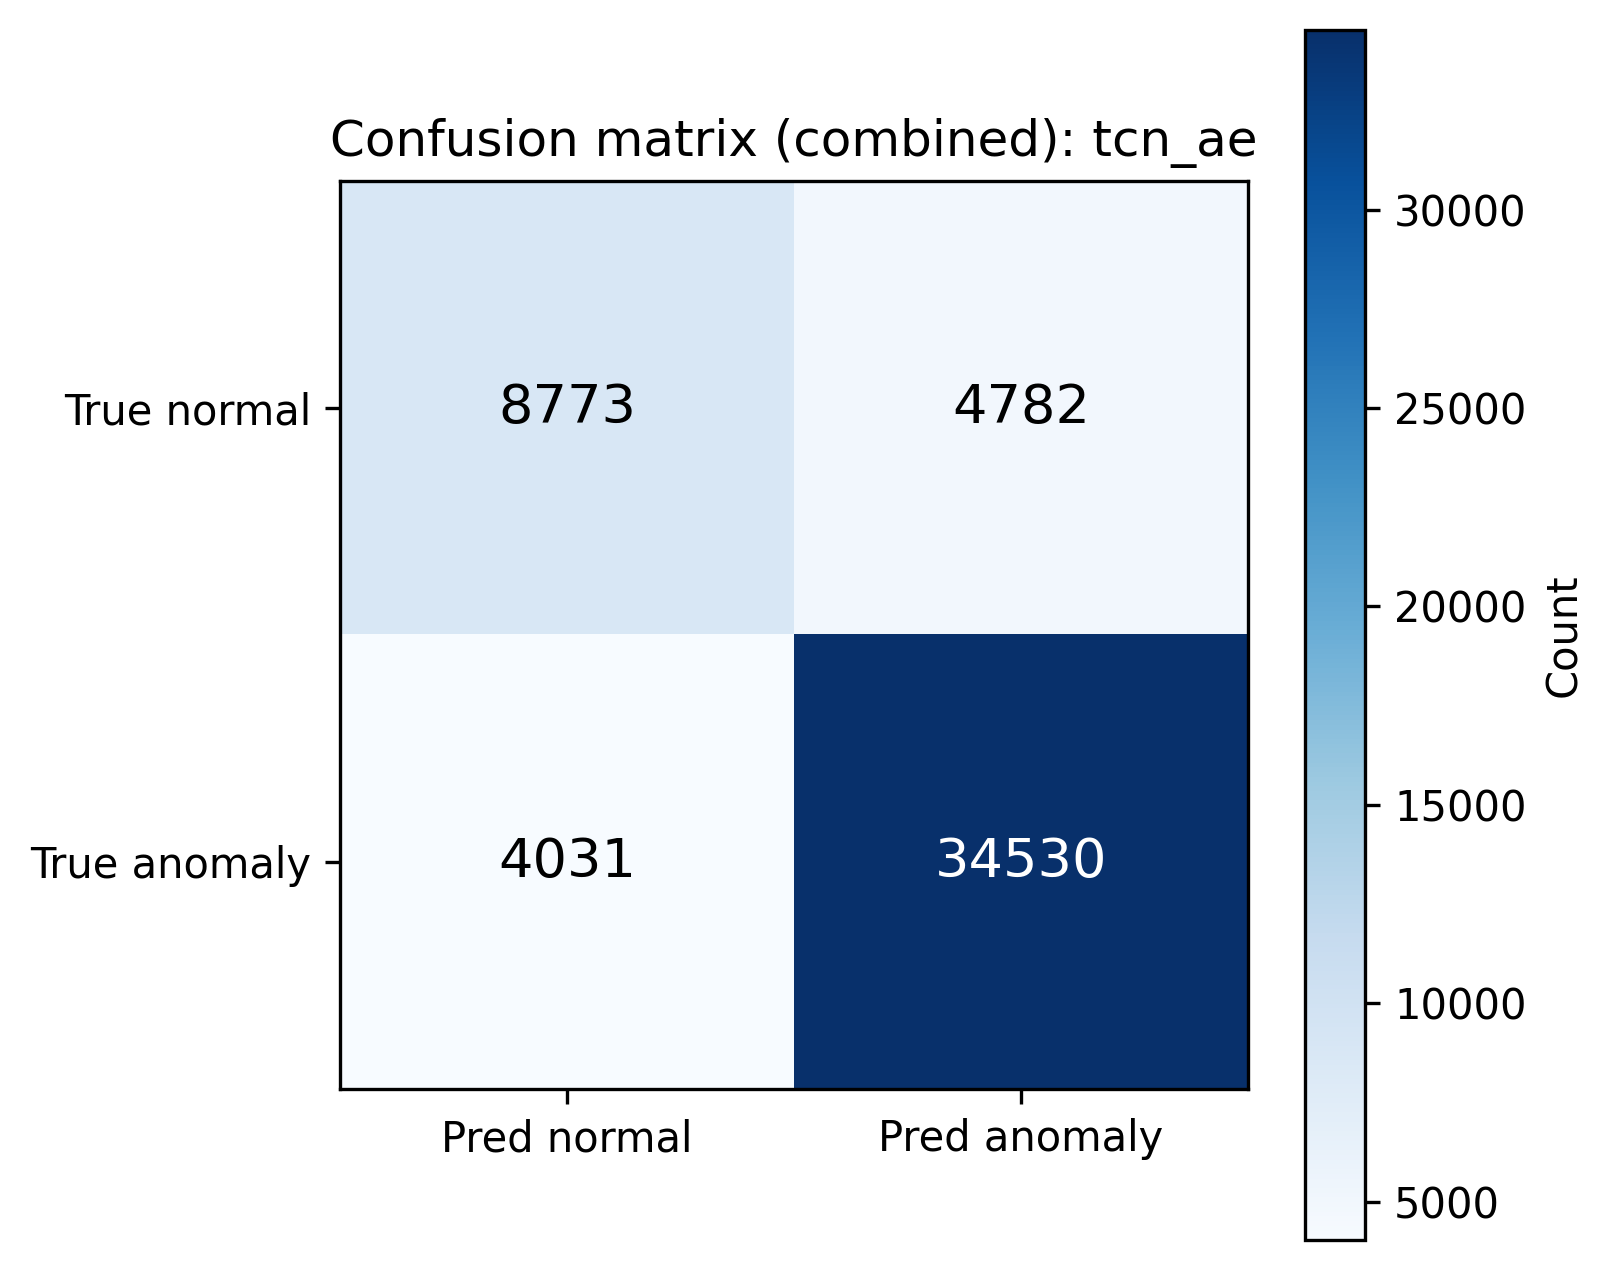

`confusion_matrix_tcn_ae_real.png`

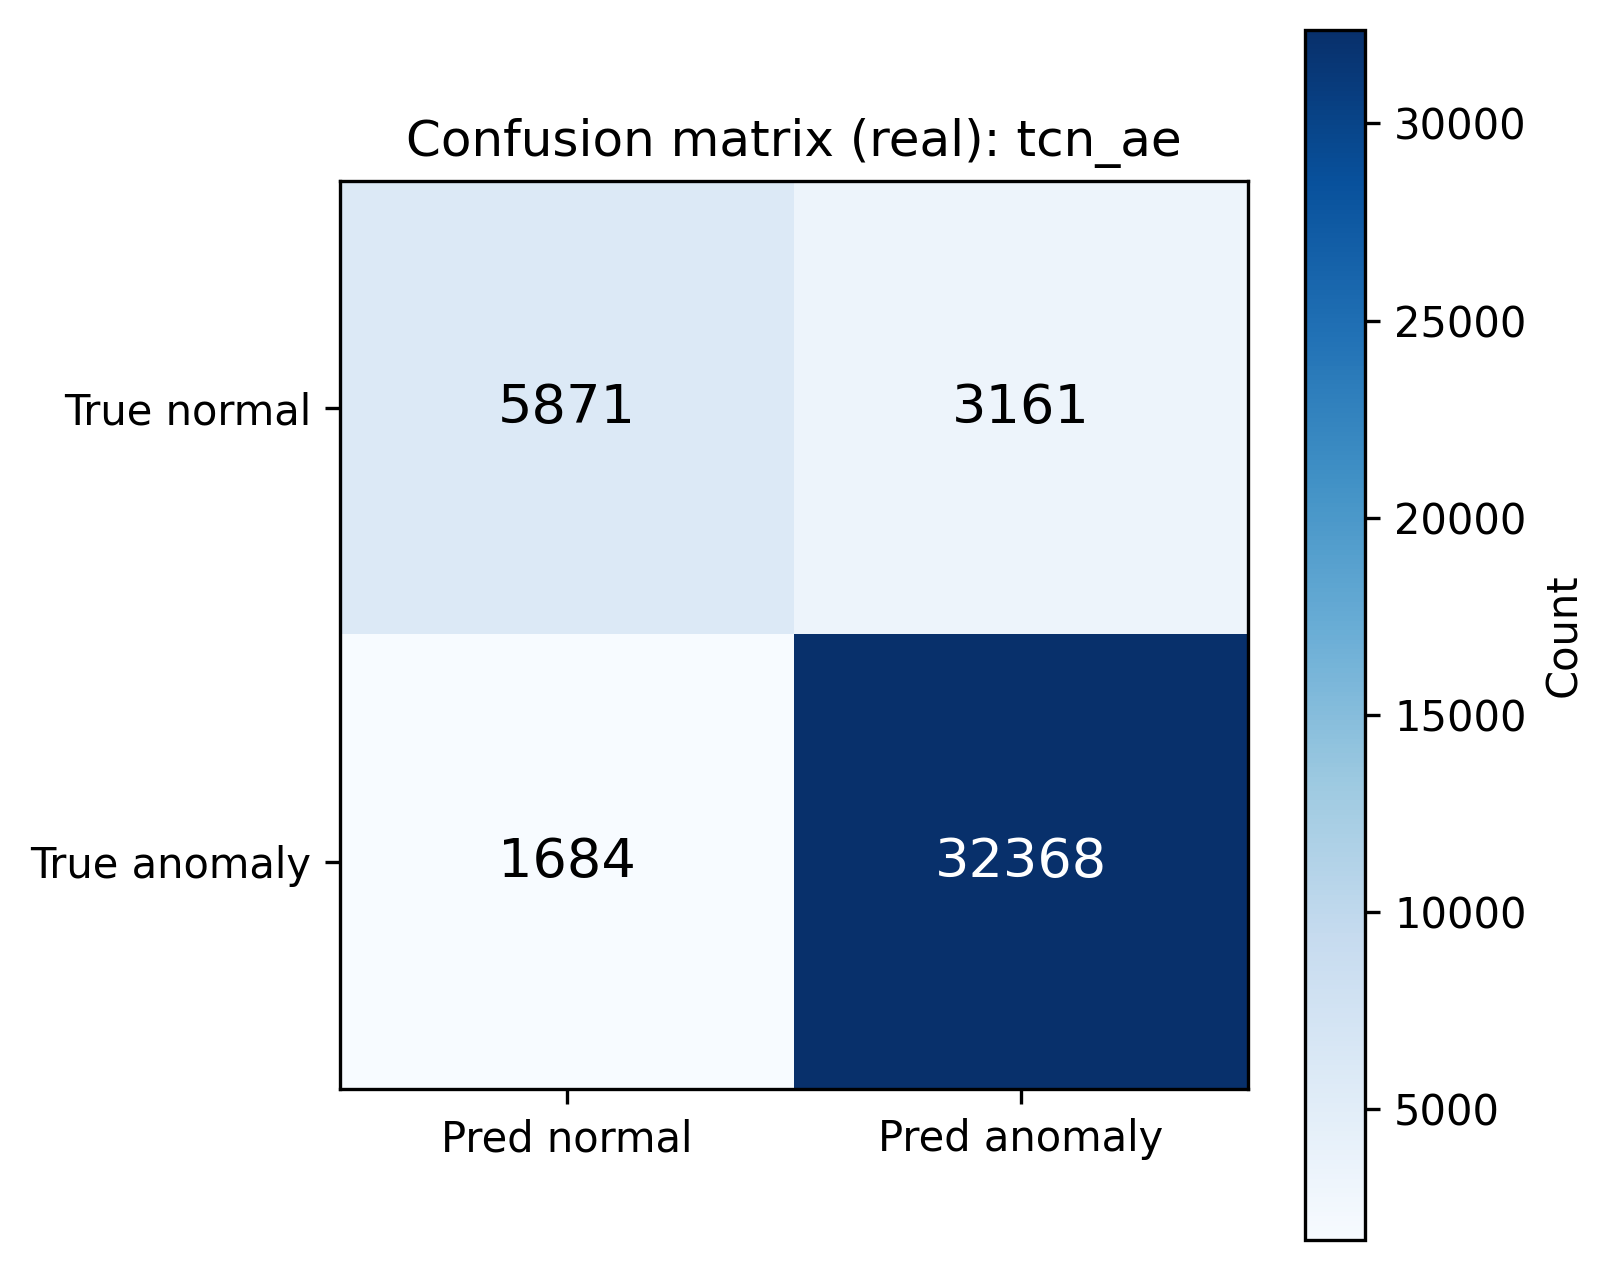

`confusion_matrix_tcn_ae_synthetic.png`

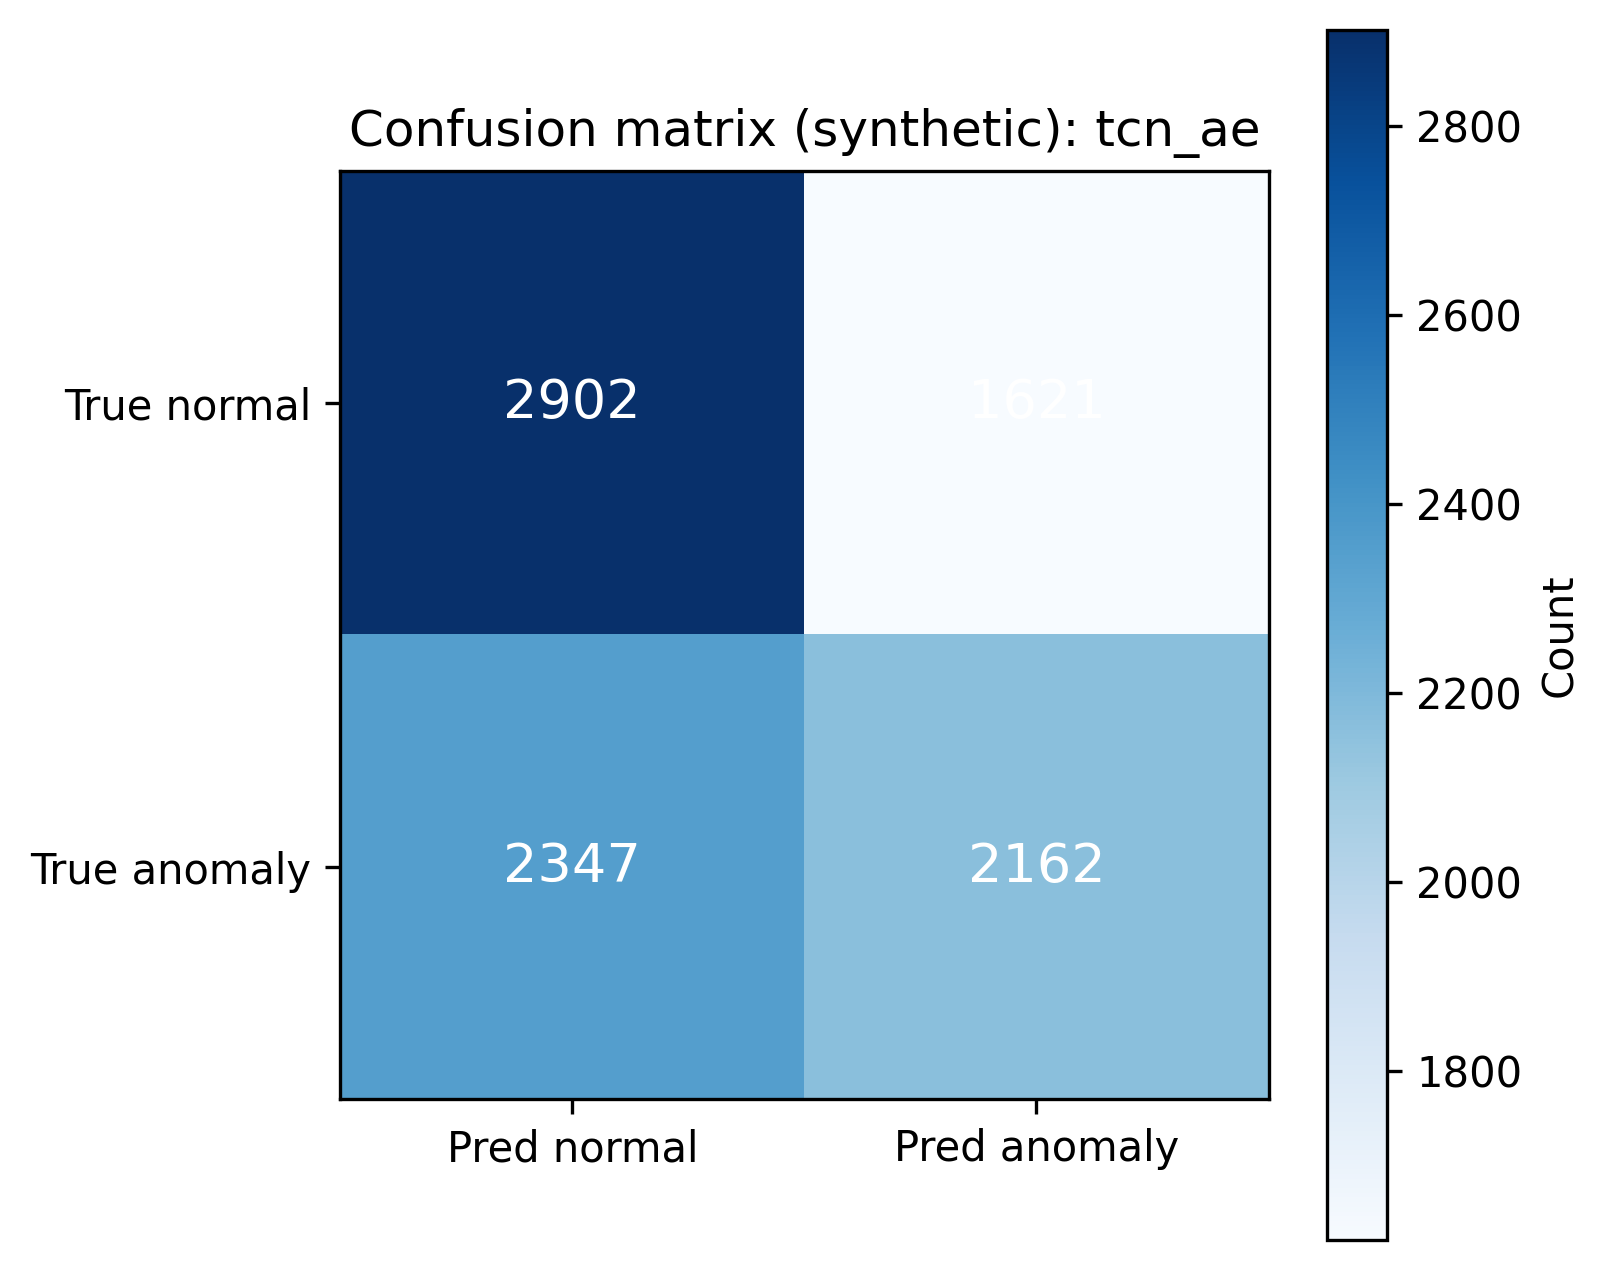

`confusion_matrix_tcn_transformer_ae_combined.png`

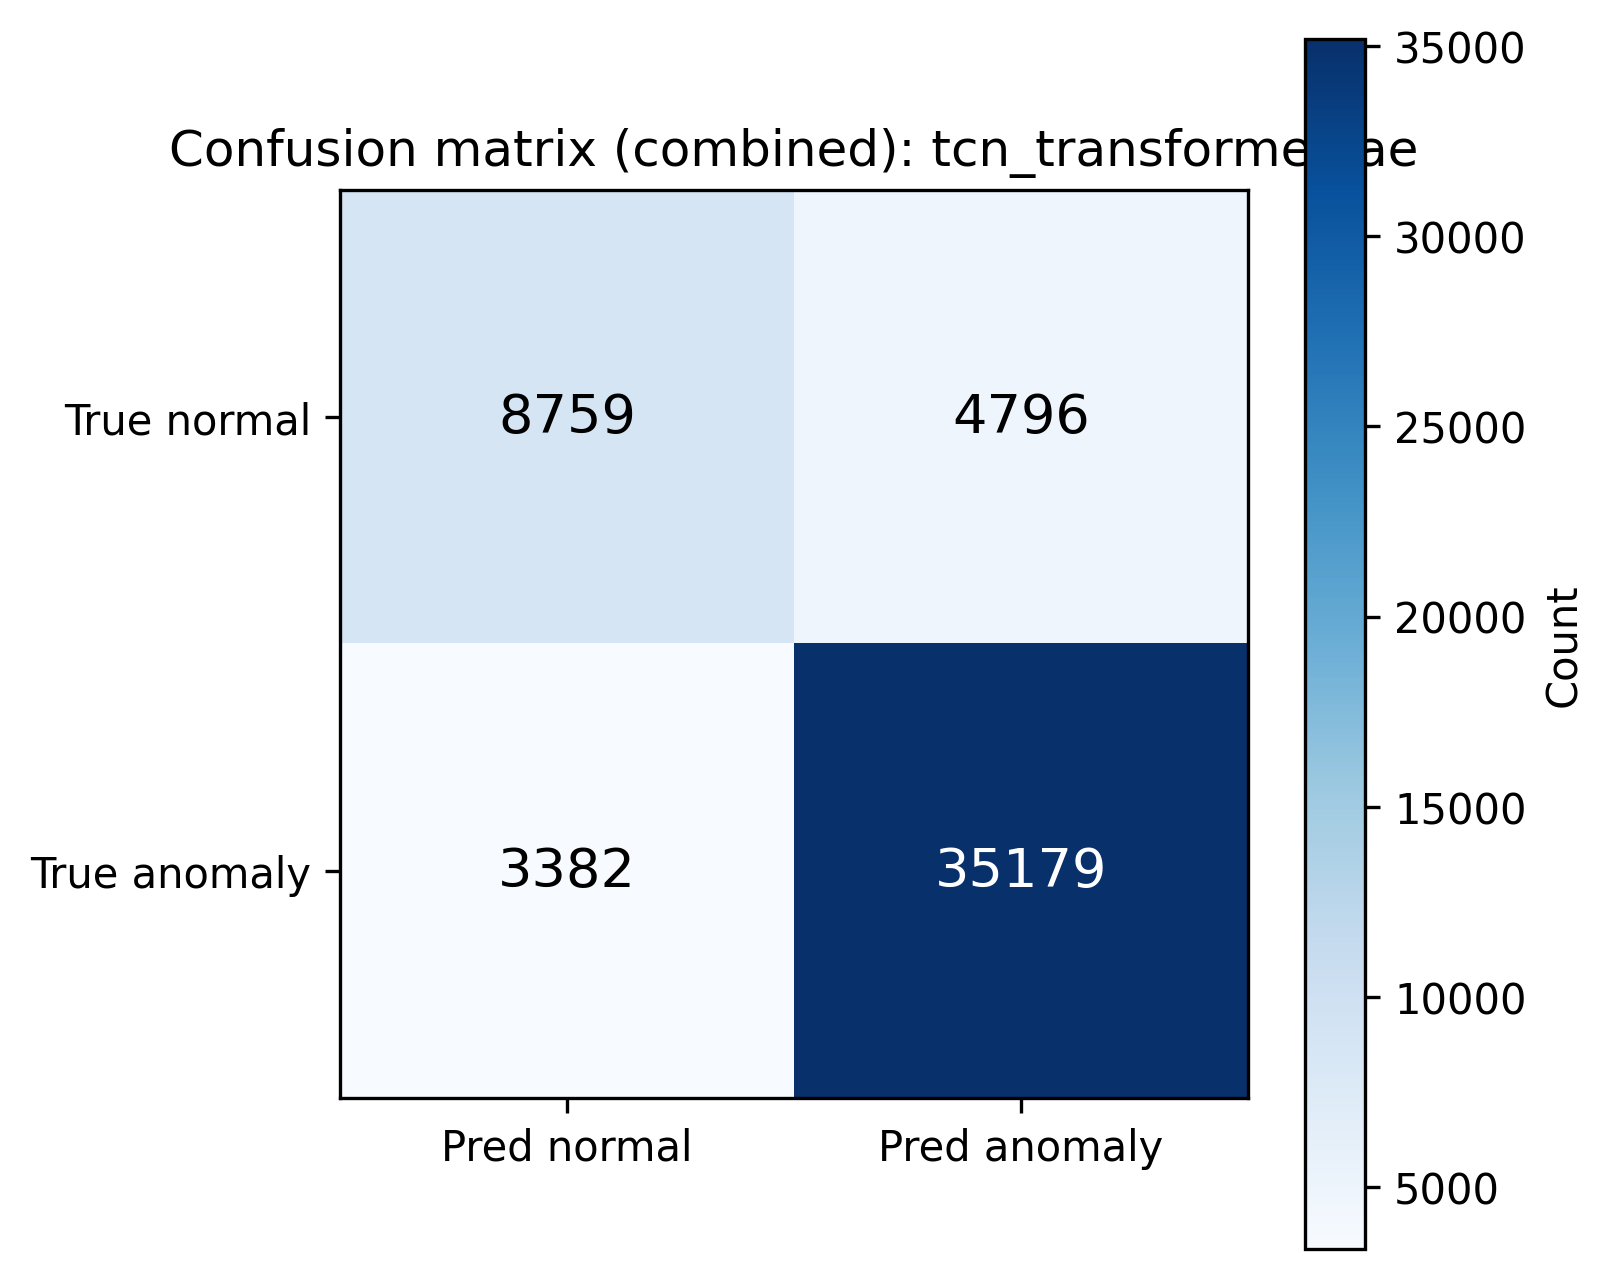

`confusion_matrix_tcn_transformer_ae_ensemble_combined.png`

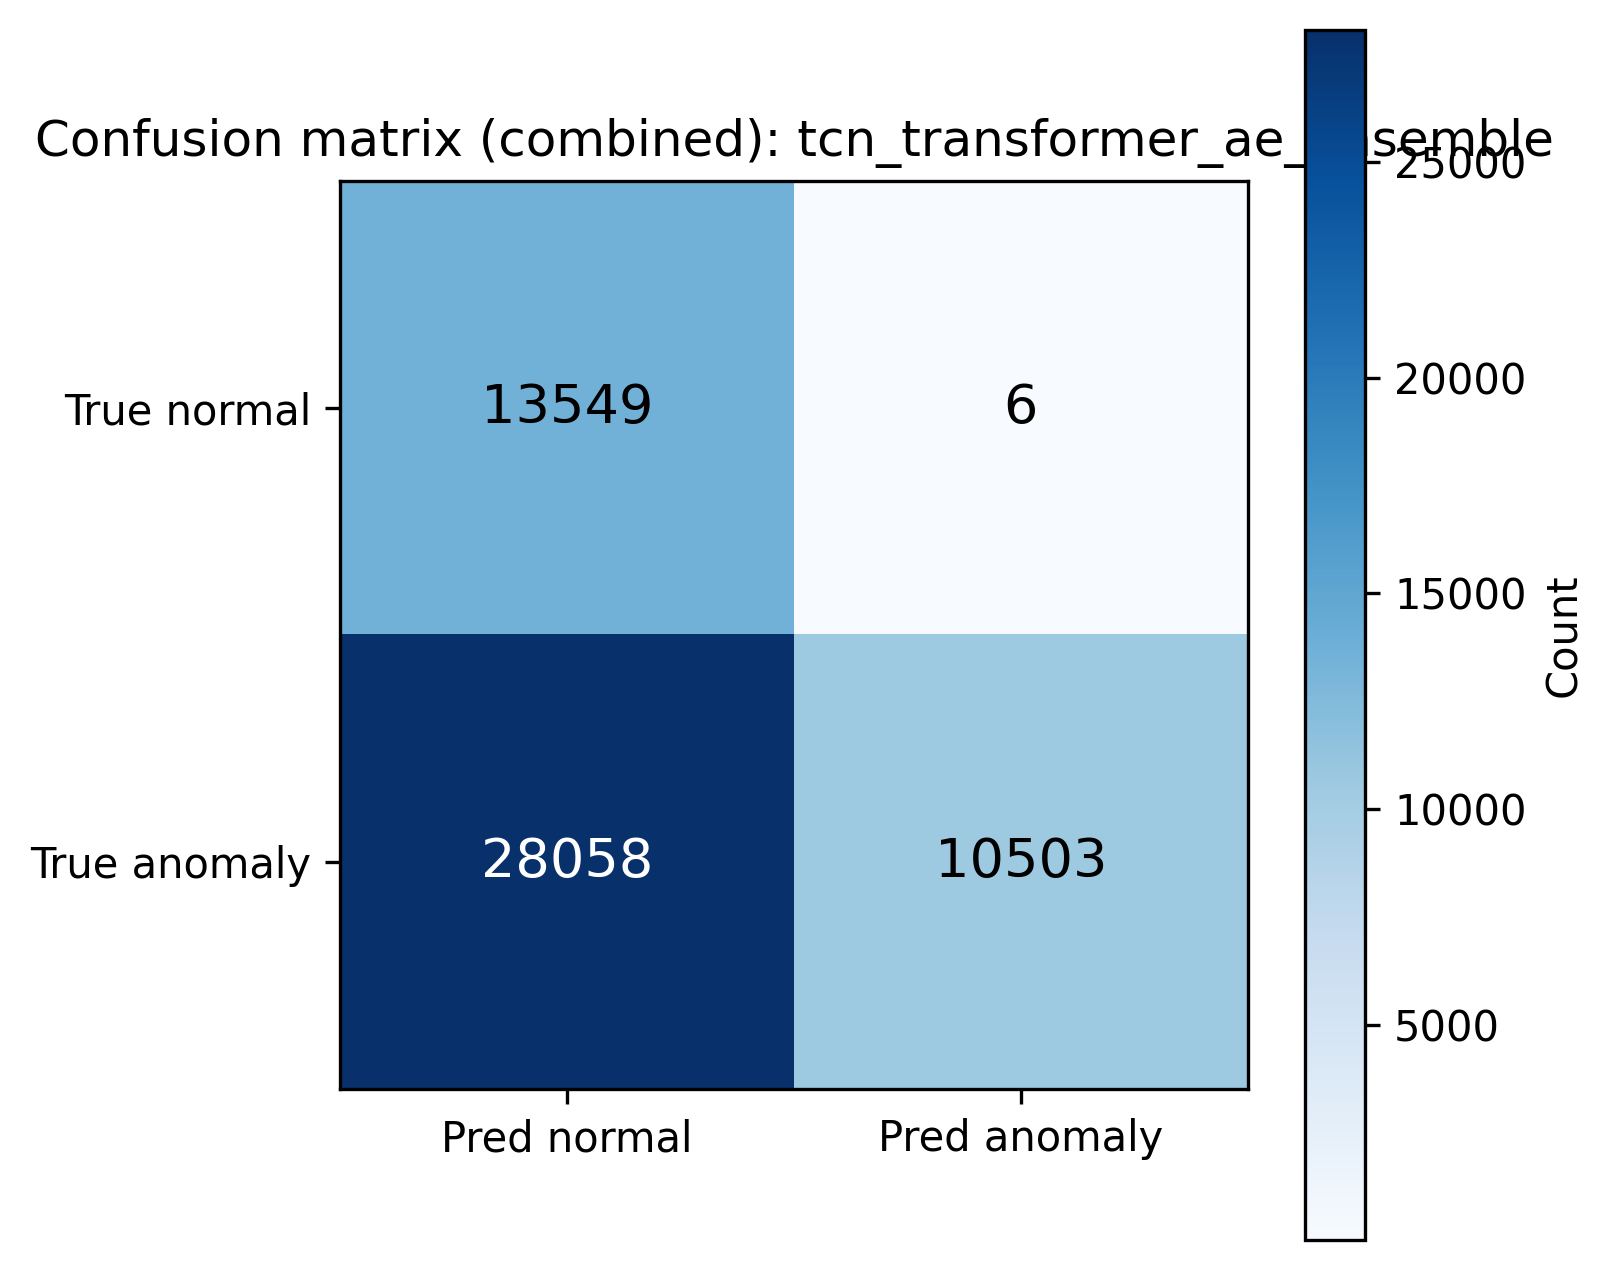

`confusion_matrix_tcn_transformer_ae_ensemble_real.png`

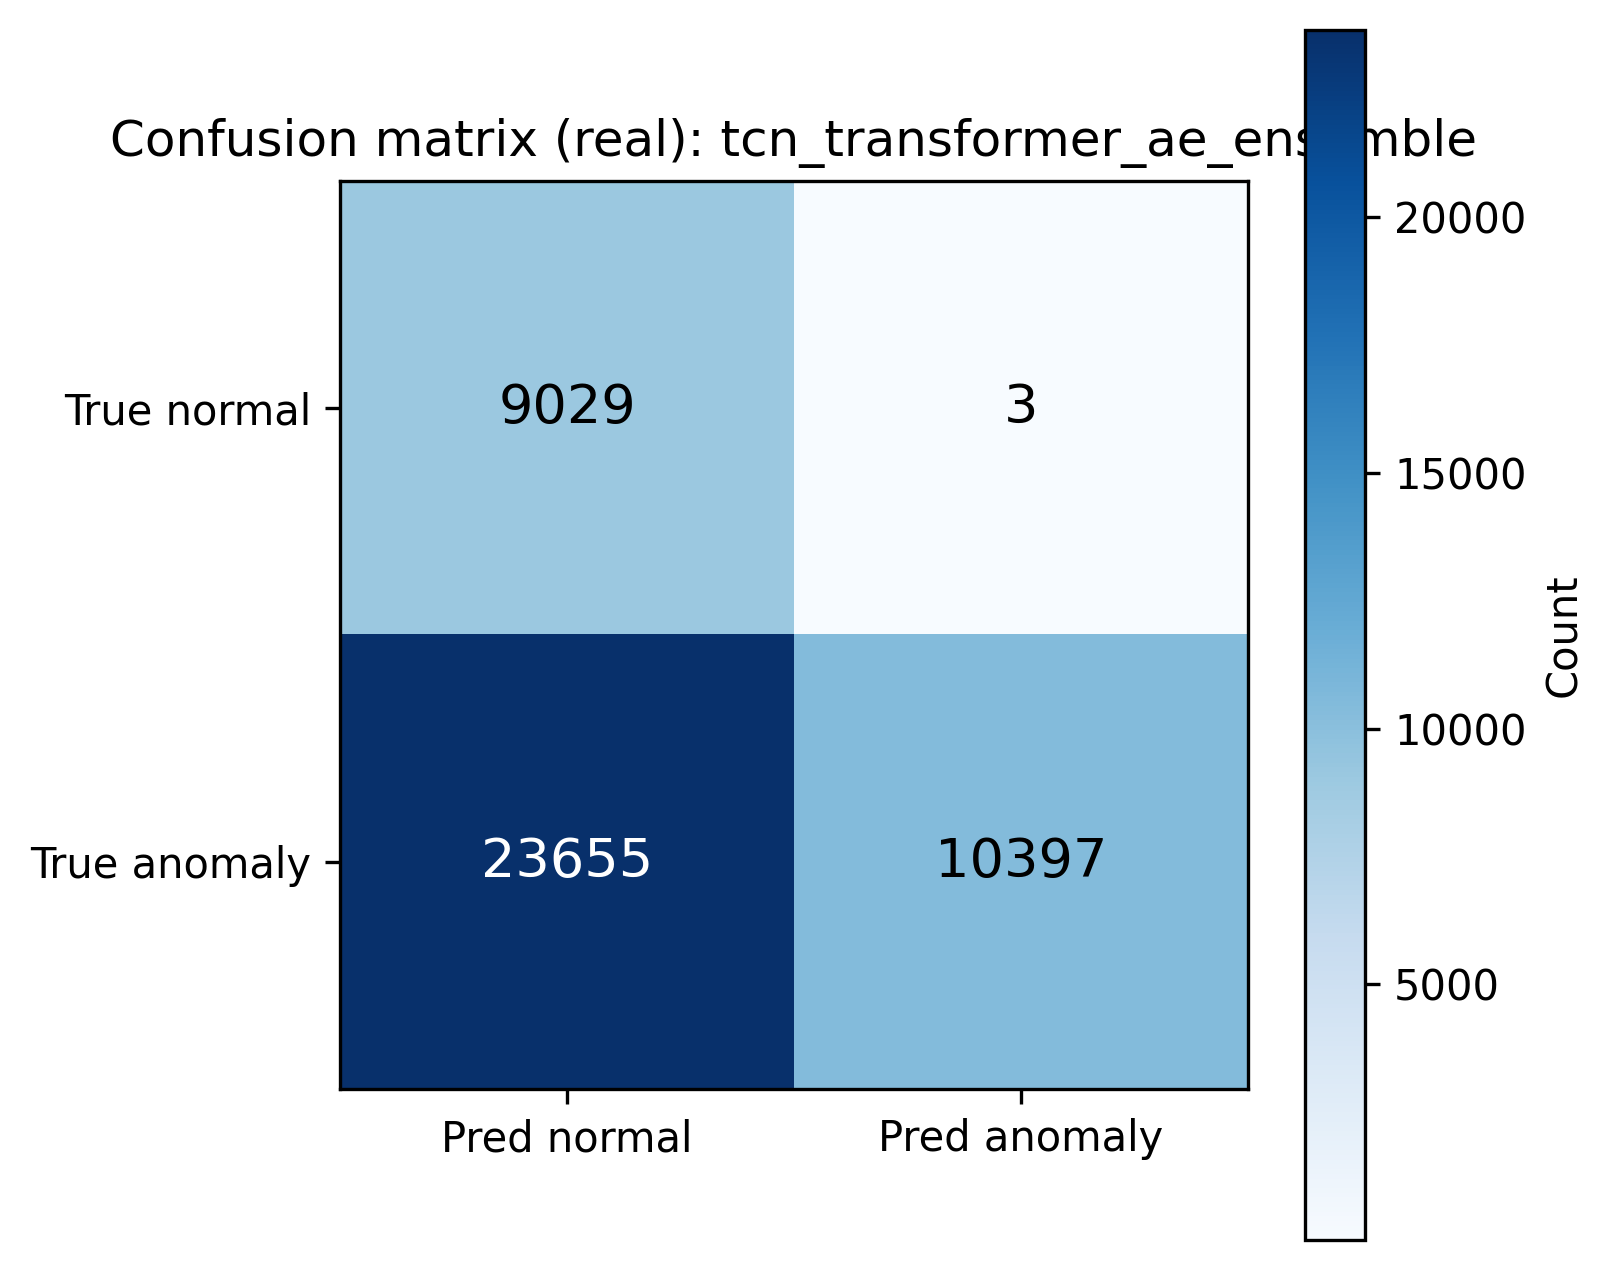

`confusion_matrix_tcn_transformer_ae_ensemble_synthetic.png`

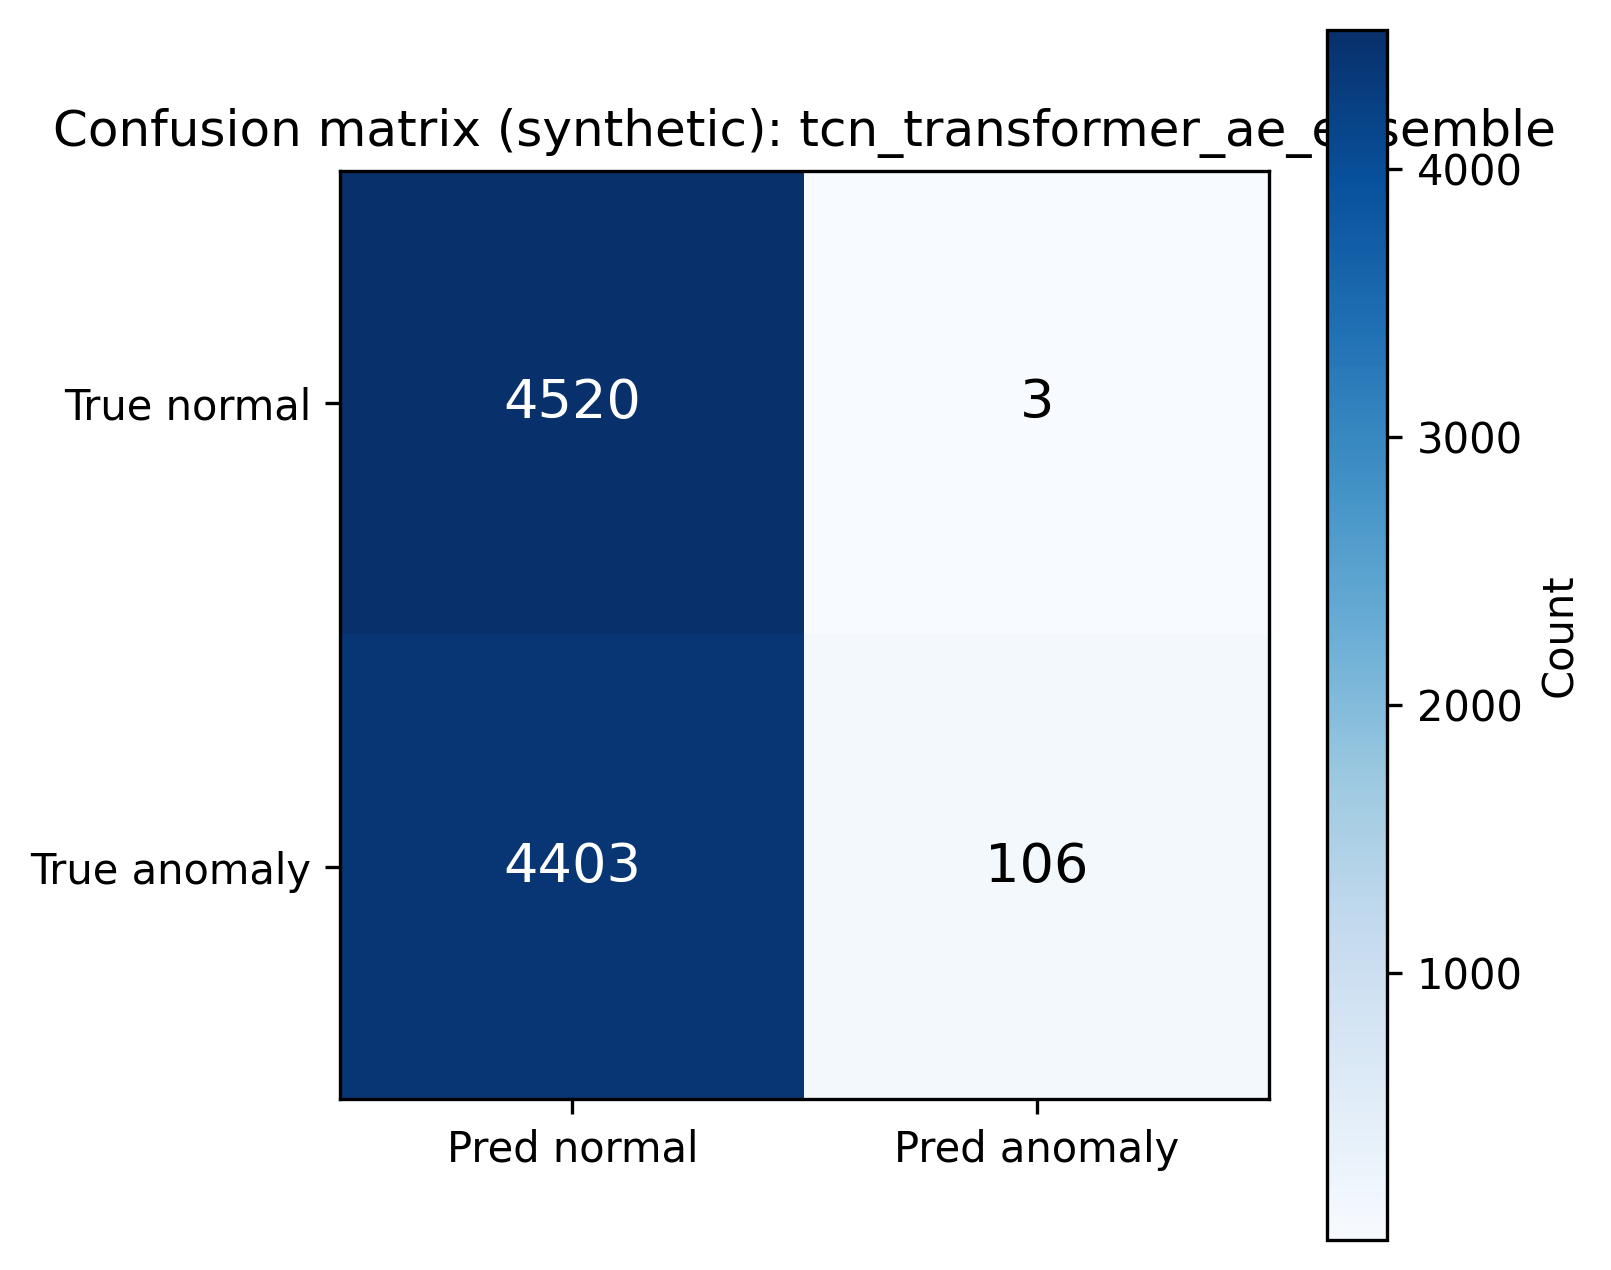

`confusion_matrix_tcn_transformer_ae_real.png`

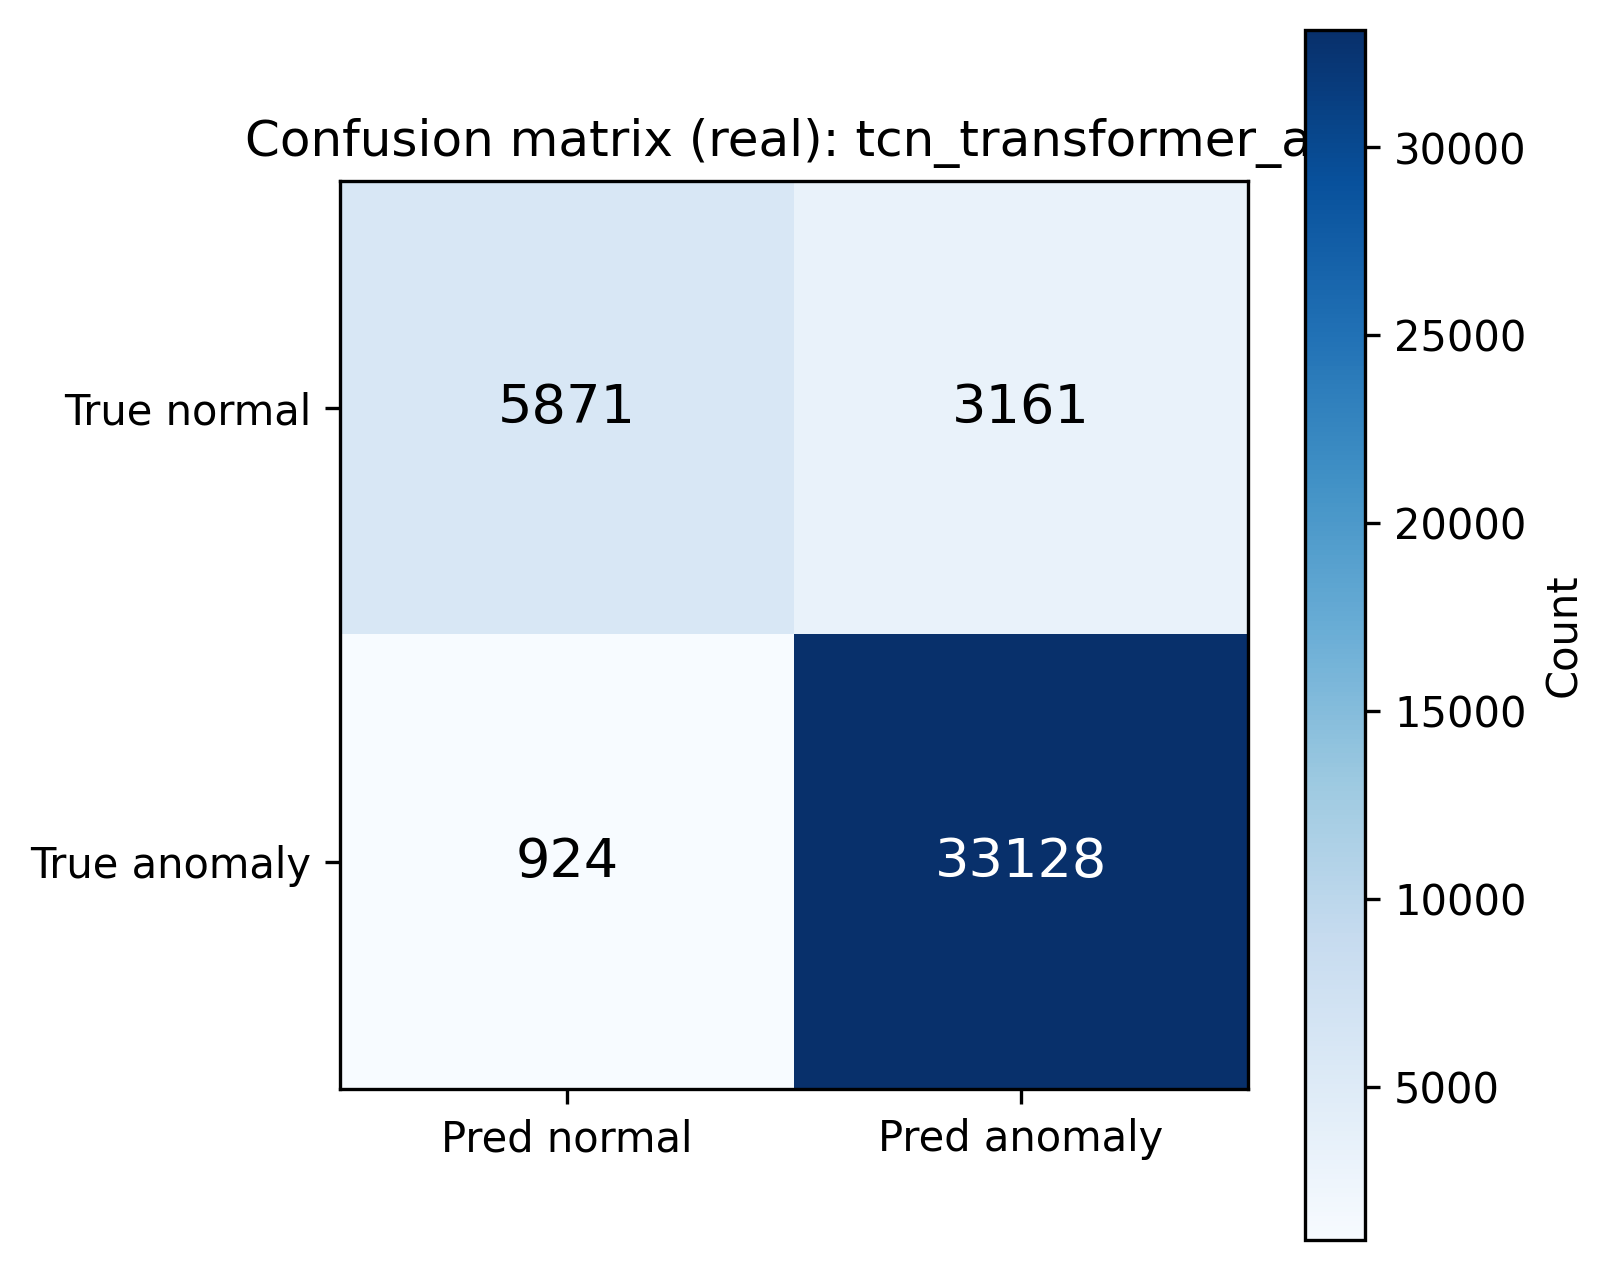

`confusion_matrix_tcn_transformer_ae_synthetic.png`

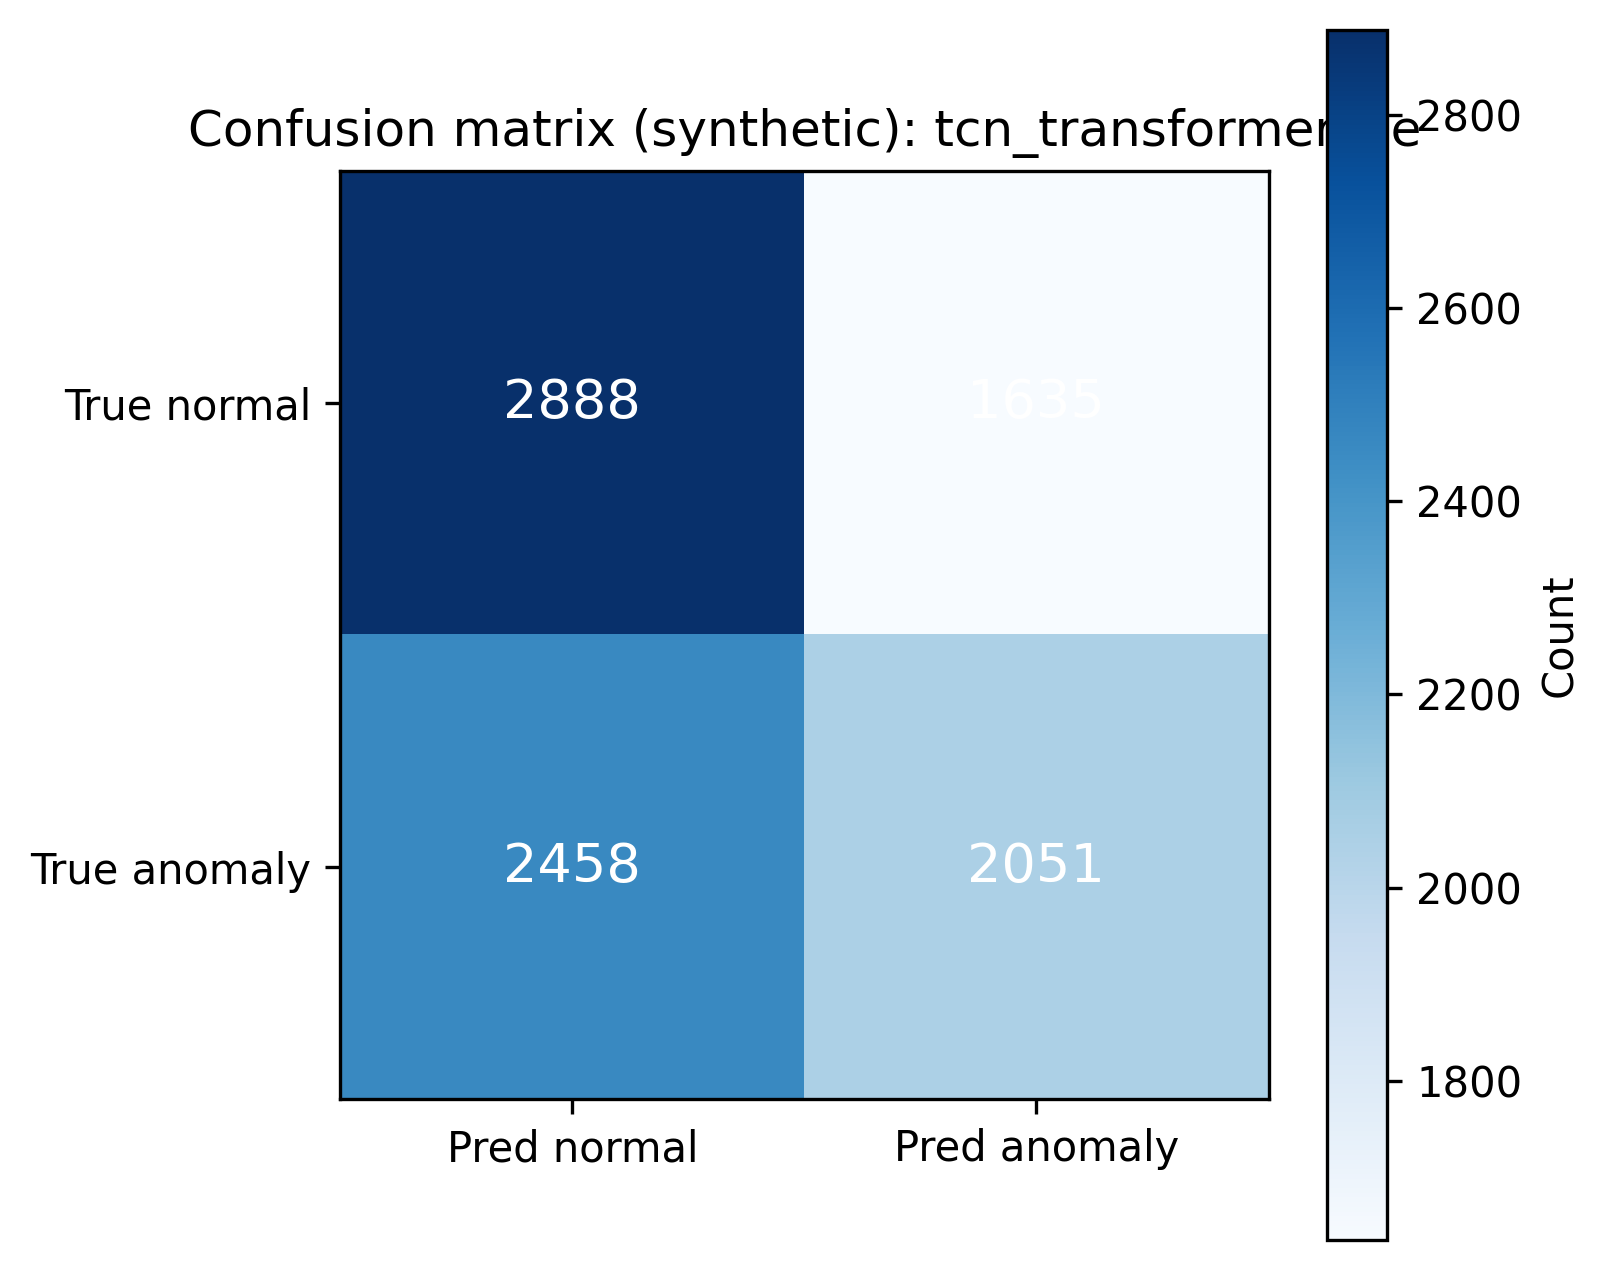

**Общие heatmap**

Пока нет `aggregate_heatmap_*.png`. Запусти localization/report для этого датасета.

In [16]:
from IPython.display import Image, Markdown, display

for dataset_name, state in DATASET_STATE.items():
    figures_dir = state['output_dir'] / 'figures'
    display(Markdown(f'### {dataset_name}'))
    if not figures_dir.exists():
        display(Markdown(f'Нет папки с картинками: `{figures_dir}`'))
        continue

    confusion_paths = sorted(figures_dir.glob('confusion_matrix_*.png'))
    confusion_overview_path = figures_dir / 'confusion_matrices_overview.png'
    heatmap_paths = sorted(figures_dir.glob('aggregate_heatmap_*.png'))

    display(Markdown('**Матрицы ошибок**'))
    if confusion_overview_path.exists():
        display(Markdown(f'`{confusion_overview_path.name}`'))
        display(Image(filename=str(confusion_overview_path)))
    if confusion_paths:
        for path in confusion_paths:
            display(Markdown(f'`{path.name}`'))
            display(Image(filename=str(path)))
    else:
        display(Markdown('Пока нет `confusion_matrix_*.png`. Запусти evaluation/report для этого датасета.'))

    display(Markdown('**Общие heatmap**'))
    if heatmap_paths:
        for path in heatmap_paths:
            display(Markdown(f'`{path.name}`'))
            display(Image(filename=str(path)))
    else:
        display(Markdown('Пока нет `aggregate_heatmap_*.png`. Запусти localization/report для этого датасета.'))
